# TVAE: Дополнительный эксперимент с альтернативным генератором

**Корнилова У. - НИУ ВШЭ, 2026**

Этот ноутбук дублирует все эксперименты, проведённые с CTGAN, но использует **TVAE** (Tabular VAE) - генератор, основанный на вариационном автоэнкодере. Цель - проверить, насколько результаты основного бенчмарка зависят от выбора генератора синтетических данных.

**Что внутри:**
- Обучение TVAE на тех же сплитах данных
- TSTR-проверка качества TVAE-синтеза
- Режим 1: LF, FP, BD атаки на смешанных датасетах
- Режим 2: инъекция TVAE-сэмплов с отравлением
- Защиты: sanitization, cleanlab, spectral filtering
- Privacy-метрики: MIA, DCR, NNDR
- Сравнение TVAE vs CTGAN по всем метрикам

## Протокол TVAE-эксперимента

| Параметр | Значение |
|---|---|
| **Генератор** | TVAESynthesizer (SDV), 300 эпох, batch_size=500 |
| **Датасеты** | Adult Census Income, Bank Marketing |
| **Модели** | LogReg, XGBoost (ядро); MLP (для backdoor + spectral defense) |
| **Атаки** | LF, FP (с $\lambda \in \{0.5, 1.0, 2.0\}$), BD |
| **Доля отравления $\rho$** | $\{0,\ 0.5\%,\ 1\%,\ 2\%,\ 5\%,\ 10\%\}$ |
| **Доля смешивания $\alpha$** | $\{0.0,\ 0.25,\ 0.5,\ 0.75,\ 1.0\}$ |
| **Случайные инициализации** | $\{42,\ 123,\ 456,\ 789,\ 1024\}$ |
| **Режимы** | Режим 1 (отравление после смешивания) + Режим 2 (инъекция синтетического яда) |
| **Защиты** | Sanitization, Cleanlab, Spectral Filtering |
| **Privacy** | MIA, DCR, NNDR |
| **Метрика** | ROC-AUC на чистой реальной отложенной выборке $D_{\text{test}}$ |

## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
PROJECT = '/content/drive/MyDrive/diploma'
os.chdir(PROJECT)

for d in ['data/synthetic', 'results/tvae', 'figures/tvae']:
    os.makedirs(d, exist_ok=True)

print(f'Working directory: {os.getcwd()}')

Working directory: /content/drive/MyDrive/diploma


In [3]:
!pip install sdv xgboost cleanlab -q

## 1. Конфигурация и загрузка сохранённого состояния

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

SEED = 42
SEEDS = [42, 123, 456, 789, 1024]
POISON_RATES = [0.005, 0.01, 0.02, 0.05, 0.10]
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]
LAMBDAS = [0.5, 1.0, 2.0]
CORE_MODELS = ['LogReg', 'XGBoost']

DATASETS = {
    'adult': 'income',
    'bank':  'y',
}

np.random.seed(SEED)
print('Config loaded.')

Config loaded.


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import xgboost as xgb

def get_core_models():
    return {
        'LogReg': LogisticRegression(max_iter=1000, random_state=SEED),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='logloss', random_state=SEED, verbosity=0),
    }

# Reconstruct scaler from saved meta.json
DS_STATE = {}
for name, target_col in DATASETS.items():
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    scaler = StandardScaler()
    scaler.mean_  = np.array(meta['scaler_mean'])
    scaler.scale_ = np.array(meta['scaler_scale'])
    scaler.var_   = scaler.scale_ ** 2
    scaler.n_features_in_ = len(meta['num_idx'])

    # Reconstruct label encoders from train_raw
    train_raw = pd.read_csv(f'data/processed/{name}/train_raw.csv')
    label_encoders = {}
    for c in meta['cat_cols']:
        if c in train_raw.columns:
            le = LabelEncoder()
            le.classes_ = np.array(sorted(train_raw[c].unique()))
            label_encoders[c] = le

    DS_STATE[name] = {
        'meta': meta,
        'scaler': scaler,
        'label_encoders': label_encoders,
        'target_col': target_col,
    }
    print(f'[{name}] meta loaded - train={meta["train_size"]}, test={meta["test_size"]}')

[adult] meta loaded - train=19536, test=6513
[bank] meta loaded - train=24712, test=8238


## 2. Обучение TVAE

TVAE (Tabular Variational AutoEncoder) - альтернативный к CTGAN табличный генератор из SDV. Если pkl-файл уже существует, обучение пропускается.

In [6]:
from sdv.single_table import TVAESynthesizer
from sdv.metadata import SingleTableMetadata

def synthesize_tvae(name, target_col, meta):
    pkl_path = f'data/synthetic/{name}_tvae.pkl'
    csv_path = f'data/synthetic/{name}_syn_tvae.csv'

    if os.path.exists(pkl_path) and os.path.exists(csv_path):
        print(f'[{name}] TVAE already trained, loading from {pkl_path}')
        syn_df = pd.read_csv(csv_path)
        return syn_df

    train_df = pd.read_csv(f'data/processed/{name}/train_raw.csv')

    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(train_df)
    for c in meta['cat_cols']:
        if c in train_df.columns:
            metadata.update_column(column_name=c, sdtype='categorical')

    synth = TVAESynthesizer(
        metadata,
        epochs=300,
        batch_size=500,
        cuda=True,
    )
    synth.fit(train_df)

    n = len(train_df)
    syn_df = synth.sample(num_rows=n)
    syn_df.to_csv(csv_path, index=False)
    synth.save(pkl_path)

    print(f'[{name}] TVAE synthesized {len(syn_df)} rows')
    print(f'Target dist (syn):  {syn_df[target_col].value_counts().to_dict()}')
    print(f'Target dist (real): {train_df[target_col].value_counts().to_dict()}')
    return syn_df

for ds_name, ds_info in DS_STATE.items():
    ds_info['syn_df'] = synthesize_tvae(ds_name, ds_info['target_col'], ds_info['meta'])

[adult] TVAE already trained, loading from data/synthetic/adult_tvae.pkl
[bank] TVAE already trained, loading from data/synthetic/bank_tvae.pkl


## 3. TSTR проверка для TVAE

Train-on-Synthetic, Test-on-Real - оценка пригодности TVAE-синтетики для downstream обучения.

In [7]:
def tstr_check_tvae(name, target_col, label_encoders, scaler_obj):
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    syn_df = pd.read_csv(f'data/synthetic/{name}_syn_tvae.csv')
    for c in meta['cat_cols']:
        if c in syn_df.columns and c in label_encoders:
            le = label_encoders[c]
            mask = syn_df[c].isin(le.classes_)
            if not mask.all():
                # Replace unknown categories with the first known one
                syn_df.loc[~mask, c] = le.classes_[0]
            syn_df[c] = le.transform(syn_df[c])

    y_syn = syn_df[target_col].values
    X_syn = syn_df.drop(columns=[target_col]).values.astype(float)
    X_syn[:, meta['num_idx']] = scaler_obj.transform(X_syn[:, meta['num_idx']])

    X_train_real = np.load(f'data/processed/{name}/X_train.npy')
    y_train_real = np.load(f'data/processed/{name}/y_train.npy')

    lr_real = LogisticRegression(max_iter=1000, random_state=SEED).fit(X_train_real, y_train_real)
    lr_syn  = LogisticRegression(max_iter=1000, random_state=SEED).fit(X_syn, y_syn)

    auc_real = roc_auc_score(y_test, lr_real.predict_proba(X_test)[:, 1])
    auc_syn  = roc_auc_score(y_test, lr_syn.predict_proba(X_test)[:, 1])
    gap = auc_real - auc_syn

    print(f'[{name}] TVAE TSTR: real_AUC={auc_real:.4f}, syn_AUC={auc_syn:.4f}, gap={gap:.4f}')
    if gap > 0.15:
        print(f'  [!] Large TSTR gap for TVAE on {name}')
    return auc_real, auc_syn, gap

# Also save the encoded synthetic dataset for downstream use
def encode_syn_to_npy(name, target_col, meta, label_encoders, scaler_obj):
    syn_df = pd.read_csv(f'data/synthetic/{name}_syn_tvae.csv')
    for c in meta['cat_cols']:
        if c in syn_df.columns and c in label_encoders:
            le = label_encoders[c]
            mask = syn_df[c].isin(le.classes_)
            if not mask.all():
                syn_df.loc[~mask, c] = le.classes_[0]
            syn_df[c] = le.transform(syn_df[c])

    y_syn = syn_df[target_col].values
    X_syn = syn_df.drop(columns=[target_col]).values.astype(float)
    X_syn[:, meta['num_idx']] = scaler_obj.transform(X_syn[:, meta['num_idx']])
    return X_syn, y_syn

tstr_tvae = {}
for ds_name, ds_info in DS_STATE.items():
    r, s, g = tstr_check_tvae(ds_name, ds_info['target_col'],
                              ds_info['label_encoders'], ds_info['scaler'])
    tstr_tvae[ds_name] = {'real_auc': r, 'syn_auc': s, 'gap': g}

[adult] TVAE TSTR: real_AUC=0.8548, syn_AUC=0.7983, gap=0.0566
[bank] TVAE TSTR: real_AUC=0.9366, syn_AUC=0.8569, gap=0.0798


## 4. Смешанные датасеты $D(\alpha)$ на основе TVAE

In [8]:
def create_mixed_datasets_tvae(name, target_col, label_encoders, scaler_obj):
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)
    train_df = pd.read_csv(f'data/processed/{name}/train_raw.csv')
    syn_df = pd.read_csv(f'data/synthetic/{name}_syn_tvae.csv')

    n = len(train_df)

    # alpha=0.0 (fully synthetic)
    X_syn, y_syn = encode_syn_to_npy(name, target_col, meta, label_encoders, scaler_obj)
    np.save(f'data/processed/{name}/X_train_alpha_0.00_tvae.npy', X_syn)
    np.save(f'data/processed/{name}/y_train_alpha_0.00_tvae.npy', y_syn)
    print(f'  [{name}] alpha=0.00 (TVAE syn): {len(y_syn)} rows')

    # Real (alpha=1.0): reuse existing CTGAN baseline file (real is the same)
    X_real = np.load(f'data/processed/{name}/X_train_alpha_1.00.npy')
    y_real = np.load(f'data/processed/{name}/y_train_alpha_1.00.npy')
    np.save(f'data/processed/{name}/X_train_alpha_1.00_tvae.npy', X_real)
    np.save(f'data/processed/{name}/y_train_alpha_1.00_tvae.npy', y_real)

    # Mixed alphas
    for alpha in [0.25, 0.5, 0.75]:
        n_real = int(alpha * n)
        n_syn = n - n_real
        real_part = train_df.sample(n=n_real, random_state=SEED)
        syn_part  = syn_df.sample(n=n_syn, random_state=SEED)
        mixed = pd.concat([real_part, syn_part], ignore_index=True).sample(
            frac=1, random_state=SEED)

        for c in meta['cat_cols']:
            if c in mixed.columns and c in label_encoders:
                le = label_encoders[c]
                mask = mixed[c].isin(le.classes_)
                if not mask.all():
                    mixed.loc[~mask, c] = le.classes_[0]
                mixed[c] = le.transform(mixed[c])

        y_mix = mixed[target_col].values
        X_mix = mixed.drop(columns=[target_col]).values.astype(float)
        X_mix[:, meta['num_idx']] = scaler_obj.transform(X_mix[:, meta['num_idx']])

        tag = f'alpha_{alpha:.2f}_tvae'
        np.save(f'data/processed/{name}/X_train_{tag}.npy', X_mix)
        np.save(f'data/processed/{name}/y_train_{tag}.npy', y_mix)
        print(f'  [{name}] alpha={alpha:.2f}: {n_real} real + {n_syn} syn = {len(y_mix)}')

for ds_name, ds_info in DS_STATE.items():
    create_mixed_datasets_tvae(ds_name, ds_info['target_col'],
                               ds_info['label_encoders'], ds_info['scaler'])
print('Mixed TVAE datasets created.')

  [adult] alpha=0.00 (TVAE syn): 19536 rows
  [adult] alpha=0.25: 4884 real + 14652 syn = 19536
  [adult] alpha=0.50: 9768 real + 9768 syn = 19536
  [adult] alpha=0.75: 14652 real + 4884 syn = 19536
  [bank] alpha=0.00 (TVAE syn): 24712 rows
  [bank] alpha=0.25: 6178 real + 18534 syn = 24712
  [bank] alpha=0.50: 12356 real + 12356 syn = 24712
  [bank] alpha=0.75: 18534 real + 6178 syn = 24712
Mixed TVAE datasets created.


## 5. Базовые модели на TVAE-датасетах

In [ ]:
def eval_metrics(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    return {'auc': roc_auc_score(y, proba),
            'acc': accuracy_score(y, pred),
            'f1':  f1_score(y, pred)}

def train_baselines_tvae(name):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    results = []
    for alpha in ALPHAS:
        tag = f'alpha_{alpha:.2f}_tvae'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for mname, model in get_core_models().items():
            model.fit(X_train, y_train)
            m = eval_metrics(model, X_test, y_test)
            results.append({'dataset': name, 'alpha': alpha, 'model': mname,
                            'generator': 'TVAE',
                            'test_auc': m['auc'], 'test_acc': m['acc'], 'test_f1': m['f1']})
            print(f'  [{name}] alpha={alpha:.2f} {mname}: '
                  f'AUC={m["auc"]:.4f} Acc={m["acc"]:.4f} F1={m["f1"]:.4f}')
    return pd.DataFrame(results)

baseline_frames = []
for ds_name in DATASETS:
    print(f'{ds_name} baselines (TVAE):')
    baseline_frames.append(train_baselines_tvae(ds_name))

baselines_tvae = pd.concat(baseline_frames, ignore_index=True)
baselines_tvae.to_csv('results/tvae/baselines_tvae.csv', index=False)
print('Saved baselines_tvae.csv')

adult baselines (TVAE):
  [adult] alpha=0.00 LogReg: AUC=0.7983 Acc=0.7763 F1=0.5465
  [adult] alpha=0.00 XGBoost: AUC=0.8797 Acc=0.8211 F1=0.6358
  [adult] alpha=0.25 LogReg: AUC=0.8422 Acc=0.8118 F1=0.5377
  [adult] alpha=0.25 XGBoost: AUC=0.9016 Acc=0.8478 F1=0.6667
  [adult] alpha=0.50 LogReg: AUC=0.8504 Acc=0.8151 F1=0.5315
  [adult] alpha=0.50 XGBoost: AUC=0.9131 Acc=0.8505 F1=0.7021
  [adult] alpha=0.75 LogReg: AUC=0.8537 Acc=0.8214 F1=0.5430
  [adult] alpha=0.75 XGBoost: AUC=0.9180 Acc=0.8586 F1=0.7013
  [adult] alpha=1.00 LogReg: AUC=0.8548 Acc=0.8267 F1=0.5588
  [adult] alpha=1.00 XGBoost: AUC=0.9217 Acc=0.8661 F1=0.6966
bank baselines (TVAE):
  [bank] alpha=0.00 LogReg: AUC=0.8569 Acc=0.8529 F1=0.4721
  [bank] alpha=0.00 XGBoost: AUC=0.9017 Acc=0.8990 F1=0.5589
  [bank] alpha=0.25 LogReg: AUC=0.9058 Acc=0.9068 F1=0.5685
  [bank] alpha=0.25 XGBoost: AUC=0.9396 Acc=0.9137 F1=0.5878
  [bank] alpha=0.50 LogReg: AUC=0.9214 Acc=0.9119 F1=0.5647
  [bank] alpha=0.50 XGBoost: AUC=0.9

## 6. Функции атак

Функции для трёх типов атак: Label Flipping (LF), Feature Perturbation (FP), Backdoor (BD).

In [11]:
def label_flip(y, rho, seed=SEED):
    rng = np.random.RandomState(seed)
    y_p = y.copy()
    n_flip = int(rho * len(y))
    idx = rng.choice(len(y), size=n_flip, replace=False)
    y_p[idx] = 1 - y_p[idx]
    return y_p, idx

def feature_perturb(X, y, rho, lam, meta, seed=SEED):
    rng = np.random.RandomState(seed)
    X_p = X.copy()
    n_poison = int(rho * len(X))
    idx = rng.choice(len(X), size=n_poison, replace=False)

    if len(meta['num_idx']) > 0:
        noise = rng.normal(0, lam, size=(n_poison, len(meta['num_idx'])))
        X_p[idx[:, None], meta['num_idx']] += noise

    if len(meta['cat_idx']) > 0:
        for i in idx:
            col = rng.choice(meta['cat_idx'])
            vals = np.unique(X[:, col])
            X_p[i, col] = rng.choice(vals)

    return X_p, idx

def backdoor_poison(X, y, rho, meta, target_label=1, seed=SEED):
    rng = np.random.RandomState(seed)
    X_p, y_p = X.copy(), y.copy()
    n_poison = int(rho * len(X))
    idx = rng.choice(len(X), size=n_poison, replace=False)

    trigger_cols = meta['num_idx'][:2] if len(meta['num_idx']) >= 2 else meta['num_idx']
    trigger_vals = [3.0] * len(trigger_cols)

    for i in idx:
        for col, val in zip(trigger_cols, trigger_vals):
            X_p[i, col] = val
        y_p[i] = target_label

    return X_p, y_p, idx, trigger_cols, trigger_vals

def apply_trigger(X, trigger_cols, trigger_vals):
    X_t = X.copy()
    for col, val in zip(trigger_cols, trigger_vals):
        X_t[:, col] = val
    return X_t

print('Attack functions defined.')

Attack functions defined.


## 7. Режим 1 - Label Flipping на TVAE-датасетах

In [ ]:
from joblib import Parallel, delayed

def lf_r1_one_seed(seed, alpha, rho, X_train, y_train, X_test, y_test, name):
    if rho == 0.0:
        y_tr = y_train.copy()
    else:
        y_tr = label_flip(y_train, rho, seed)[0]
    rows = []
    for mname, model in get_core_models().items():
        model.fit(X_train, y_tr)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        rows.append({'dataset': name, 'generator': 'TVAE', 'regime': 'R1',
                     'alpha': alpha, 'attack': 'LF',
                     'rho': rho, 'seed': seed, 'model': mname, 'test_auc': auc})
    return rows

def run_lf_r1_tvae(name):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    all_results = []
    for alpha in ALPHAS:
        tag = f'alpha_{alpha:.2f}_tvae'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for rho in [0.0] + POISON_RATES:
            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(lf_r1_one_seed)(seed, alpha, rho, X_train, y_train,
                                        X_test, y_test, name)
                for seed in SEEDS)
            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] LF alpha={alpha:.2f} rho={rho:.3f} done')

    return pd.DataFrame(all_results)

lf_r1_frames = []
for ds_name in DATASETS:
    print(f'{ds_name}: LF Regime 1 (TVAE)')
    lf_r1_frames.append(run_lf_r1_tvae(ds_name))

lf_r1_tvae = pd.concat(lf_r1_frames, ignore_index=True)
lf_r1_tvae.to_csv('results/tvae/lf_r1_tvae.csv', index=False)
print(f'Saved {len(lf_r1_tvae)} rows')

adult: LF Regime 1 (TVAE)
  [adult] LF alpha=0.00 rho=0.000 done
  [adult] LF alpha=0.00 rho=0.005 done
  [adult] LF alpha=0.00 rho=0.010 done
  [adult] LF alpha=0.00 rho=0.020 done
  [adult] LF alpha=0.00 rho=0.050 done
  [adult] LF alpha=0.00 rho=0.100 done
  [adult] LF alpha=0.25 rho=0.000 done
  [adult] LF alpha=0.25 rho=0.005 done
  [adult] LF alpha=0.25 rho=0.010 done
  [adult] LF alpha=0.25 rho=0.020 done
  [adult] LF alpha=0.25 rho=0.050 done
  [adult] LF alpha=0.25 rho=0.100 done
  [adult] LF alpha=0.50 rho=0.000 done
  [adult] LF alpha=0.50 rho=0.005 done
  [adult] LF alpha=0.50 rho=0.010 done
  [adult] LF alpha=0.50 rho=0.020 done
  [adult] LF alpha=0.50 rho=0.050 done
  [adult] LF alpha=0.50 rho=0.100 done
  [adult] LF alpha=0.75 rho=0.000 done
  [adult] LF alpha=0.75 rho=0.005 done
  [adult] LF alpha=0.75 rho=0.010 done
  [adult] LF alpha=0.75 rho=0.020 done
  [adult] LF alpha=0.75 rho=0.050 done
  [adult] LF alpha=0.75 rho=0.100 done
  [adult] LF alpha=1.00 rho=0.000 done

## 8. Режим 1 - Изменение признаков (FP) на TVAE-датасетах

In [ ]:
def fp_r1_one_seed(seed, alpha, rho, lam, X_train, y_train, meta,
                   X_test, y_test, name):
    if rho == 0.0:
        X_tr = X_train.copy()
    else:
        X_tr = feature_perturb(X_train, y_train, rho, lam, meta, seed)[0]
    rows = []
    for mname, model in get_core_models().items():
        model.fit(X_tr, y_train)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        rows.append({'dataset': name, 'generator': 'TVAE', 'regime': 'R1',
                     'alpha': alpha, 'attack': 'FP', 'rho': rho,
                     'lambda': lam, 'seed': seed,
                     'model': mname, 'test_auc': auc})
    return rows

def run_fp_r1_tvae(name):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    all_results = []
    for alpha in ALPHAS:
        tag = f'alpha_{alpha:.2f}_tvae'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for rho in [0.0] + POISON_RATES:
            for lam in (LAMBDAS if rho > 0 else [0.0]):
                seed_results = Parallel(n_jobs=-1, verbose=0)(
                    delayed(fp_r1_one_seed)(seed, alpha, rho, lam,
                                            X_train, y_train, meta,
                                            X_test, y_test, name)
                    for seed in SEEDS)
                for rows in seed_results:
                    all_results.extend(rows)
                print(f'  [{name}] FP alpha={alpha:.2f} rho={rho:.3f} lambda={lam} done')

    return pd.DataFrame(all_results)

fp_r1_frames = []
for ds_name in DATASETS:
    print(f'{ds_name}: FP Regime 1 (TVAE)')
    fp_r1_frames.append(run_fp_r1_tvae(ds_name))

fp_r1_tvae = pd.concat(fp_r1_frames, ignore_index=True)
fp_r1_tvae.to_csv('results/tvae/fp_r1_tvae.csv', index=False)
print(f'Saved {len(fp_r1_tvae)} rows')

adult: FP Regime 1 (TVAE)
  [adult] FP alpha=0.00 rho=0.000 lambda=0.0 done
  [adult] FP alpha=0.00 rho=0.005 lambda=0.5 done
  [adult] FP alpha=0.00 rho=0.005 lambda=1.0 done
  [adult] FP alpha=0.00 rho=0.005 lambda=2.0 done
  [adult] FP alpha=0.00 rho=0.010 lambda=0.5 done
  [adult] FP alpha=0.00 rho=0.010 lambda=1.0 done
  [adult] FP alpha=0.00 rho=0.010 lambda=2.0 done
  [adult] FP alpha=0.00 rho=0.020 lambda=0.5 done
  [adult] FP alpha=0.00 rho=0.020 lambda=1.0 done
  [adult] FP alpha=0.00 rho=0.020 lambda=2.0 done
  [adult] FP alpha=0.00 rho=0.050 lambda=0.5 done
  [adult] FP alpha=0.00 rho=0.050 lambda=1.0 done
  [adult] FP alpha=0.00 rho=0.050 lambda=2.0 done
  [adult] FP alpha=0.00 rho=0.100 lambda=0.5 done
  [adult] FP alpha=0.00 rho=0.100 lambda=1.0 done
  [adult] FP alpha=0.00 rho=0.100 lambda=2.0 done
  [adult] FP alpha=0.25 rho=0.000 lambda=0.0 done
  [adult] FP alpha=0.25 rho=0.005 lambda=0.5 done
  [adult] FP alpha=0.25 rho=0.005 lambda=1.0 done
  [adult] FP alpha=0.25 

## 9. Режим 1 - Backdoor (BD) на TVAE-датасетах

## Sanity-check триггерного паттерна

Согласно методологии BD-атак, триггер должен быть редким и не должен сам по себе коррелировать с целевой меткой в реальных данных. Иначе высокий ASR при $\rho=0$ означает, что мы измеряем не успех бэкдора, а статистическую связь признаков с target. Здесь проверяем эти свойства.

In [9]:
def trigger_sanity_check_tvae(name, target_label=1):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    X_train = np.load(f'data/processed/{name}/X_train.npy')
    y_train = np.load(f'data/processed/{name}/y_train.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    trigger_cols = meta['num_idx'][:2] if len(meta['num_idx']) >= 2 else meta['num_idx']
    trigger_vals = [3.0] * len(trigger_cols)
    tol = 0.1

    print(f'[{name}] Trigger sanity check')
    print(f'  Trigger cols: {[meta["feature_names"][c] for c in trigger_cols]}')

    for split_name, X, y in [('train', X_train, y_train), ('test', X_test, y_test)]:
        matches = np.all(np.abs(X[:, trigger_cols] - trigger_vals) < tol, axis=1)
        freq = matches.mean()
        y_freq = y[matches].mean() if matches.sum() > 0 else float('nan')
        print(f'  [{split_name}] natural trigger frequency = {freq:.4f}, '
              f'P(y=1 | trigger) = {y_freq:.4f} (vs base rate {y.mean():.4f})')

    target_rate = (y_test == target_label).mean()
    print(f'  Test base rate for y={target_label}: {target_rate:.4f}')
    print()

for ds_name in DATASETS:
    trigger_sanity_check_tvae(ds_name)

[adult] Trigger sanity check
  Trigger cols: ['age', 'fnlwgt']
  [train] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.2408)
  [test] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.2407)
  Test base rate for y=1: 0.2407

[bank] Trigger sanity check
  Trigger cols: ['age', 'duration']
  [train] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.1127)
  [test] natural trigger frequency = 0.0000, P(y=1 | trigger) = nan (vs base rate 0.1126)
  Test base rate for y=1: 0.1126



In [12]:
from sklearn.neural_network import MLPClassifier
from joblib import Parallel, delayed

def get_all_models():
    return {
        'LogReg': LogisticRegression(max_iter=1000, random_state=SEED),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric='logloss', random_state=SEED, verbosity=0),
        'MLP': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                             early_stopping=True, random_state=SEED, verbose=False),
    }


def compute_asr_metrics(model, X_test, y_test, X_test_trig, target_label):
    preds_trig = model.predict(X_test_trig)
    asr_full = (preds_trig == target_label).mean()
    nontarget_mask = (y_test != target_label)
    if nontarget_mask.sum() > 0:
        asr_nontarget = (preds_trig[nontarget_mask] == target_label).mean()
    else:
        asr_nontarget = float('nan')
    return asr_full, asr_nontarget


def bd_r1_one_seed(seed, alpha, rho, X_train, y_train, meta,
                   X_test, y_test, name, target_label=1):
    if rho == 0.0:
        X_tr, y_tr = X_train.copy(), y_train.copy()
        trigger_cols = meta['num_idx'][:2]
        trigger_vals = [3.0] * len(trigger_cols)
    else:
        X_tr, y_tr, _, trigger_cols, trigger_vals = backdoor_poison(
            X_train, y_train, rho, meta, target_label=target_label, seed=seed)

    X_test_trig = apply_trigger(X_test, trigger_cols, trigger_vals)

    rows = []
    for mname, model in get_all_models().items():
        model.fit(X_tr, y_tr)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        asr_full, asr_nontarget = compute_asr_metrics(
            model, X_test, y_test, X_test_trig, target_label)
        rows.append({'dataset': name, 'generator': 'TVAE', 'regime': 'R1',
                     'alpha': alpha, 'attack': 'BD', 'rho': rho,
                     'seed': seed, 'model': mname,
                     'test_auc': auc,
                     'asr': asr_full,
                     'asr_nontarget': asr_nontarget})
    return rows

def run_bd_r1_tvae(name, target_label=1):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    all_results = []
    for alpha in ALPHAS:
        tag = f'alpha_{alpha:.2f}_tvae'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for rho in [0.0] + POISON_RATES:
            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(bd_r1_one_seed)(seed, alpha, rho, X_train, y_train,
                                        meta, X_test, y_test, name, target_label)
                for seed in SEEDS)
            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] BD alpha={alpha:.2f} rho={rho:.3f} done')

    df = pd.DataFrame(all_results)

    df['asr_delta'] = float('nan')
    df['asr_nontarget_delta'] = float('nan')
    for (ds, a, m), sub in df.groupby(['dataset', 'alpha', 'model']):
        clean_full = sub.loc[sub['rho'] == 0.0, 'asr'].mean()
        clean_nt   = sub.loc[sub['rho'] == 0.0, 'asr_nontarget'].mean()
        mask = (df['dataset'] == ds) & (df['alpha'] == a) & (df['model'] == m)
        df.loc[mask, 'asr_delta']           = df.loc[mask, 'asr'] - clean_full
        df.loc[mask, 'asr_nontarget_delta'] = df.loc[mask, 'asr_nontarget'] - clean_nt

    return df

bd_r1_frames = []
for ds_name in DATASETS:
    print(f'{ds_name}: BD Regime 1 (TVAE)')
    bd_r1_frames.append(run_bd_r1_tvae(ds_name))

bd_r1_tvae = pd.concat(bd_r1_frames, ignore_index=True)
bd_r1_tvae.to_csv('results/tvae/bd_r1_tvae.csv', index=False)
print(f'Saved {len(bd_r1_tvae)} rows')

adult: BD Regime 1 (TVAE)
  [adult] BD alpha=0.00 rho=0.000 done
  [adult] BD alpha=0.00 rho=0.005 done
  [adult] BD alpha=0.00 rho=0.010 done
  [adult] BD alpha=0.00 rho=0.020 done
  [adult] BD alpha=0.00 rho=0.050 done
  [adult] BD alpha=0.00 rho=0.100 done
  [adult] BD alpha=0.25 rho=0.000 done
  [adult] BD alpha=0.25 rho=0.005 done
  [adult] BD alpha=0.25 rho=0.010 done
  [adult] BD alpha=0.25 rho=0.020 done
  [adult] BD alpha=0.25 rho=0.050 done
  [adult] BD alpha=0.25 rho=0.100 done
  [adult] BD alpha=0.50 rho=0.000 done
  [adult] BD alpha=0.50 rho=0.005 done
  [adult] BD alpha=0.50 rho=0.010 done
  [adult] BD alpha=0.50 rho=0.020 done
  [adult] BD alpha=0.50 rho=0.050 done
  [adult] BD alpha=0.50 rho=0.100 done
  [adult] BD alpha=0.75 rho=0.000 done
  [adult] BD alpha=0.75 rho=0.005 done
  [adult] BD alpha=0.75 rho=0.010 done
  [adult] BD alpha=0.75 rho=0.020 done
  [adult] BD alpha=0.75 rho=0.050 done
  [adult] BD alpha=0.75 rho=0.100 done
  [adult] BD alpha=1.00 rho=0.000 done

## 10. Кривые деградации (Режим 1, TVAE)

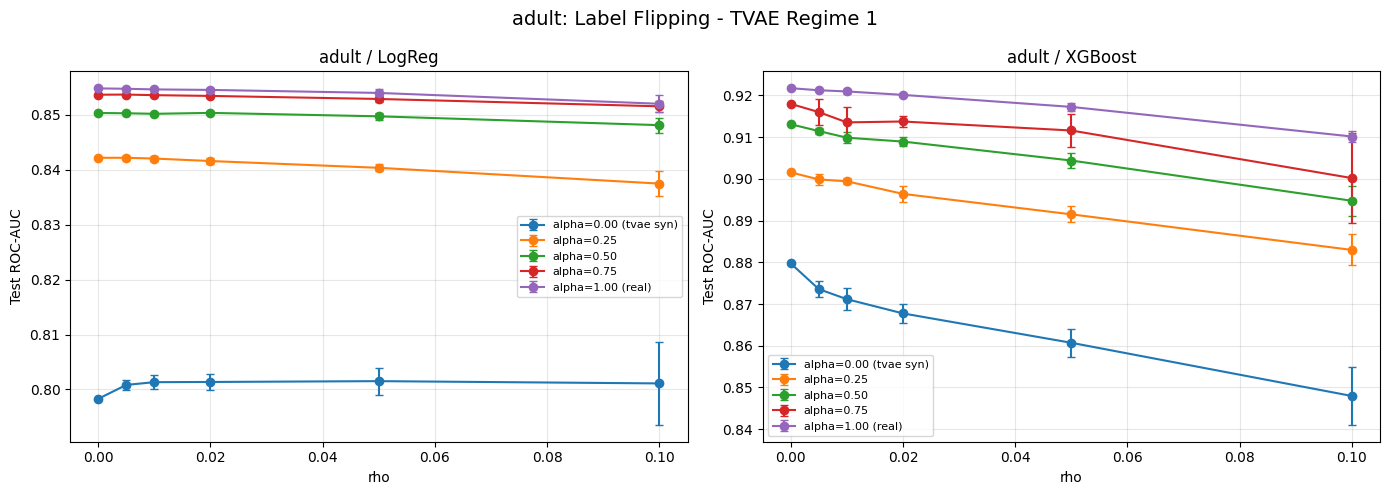

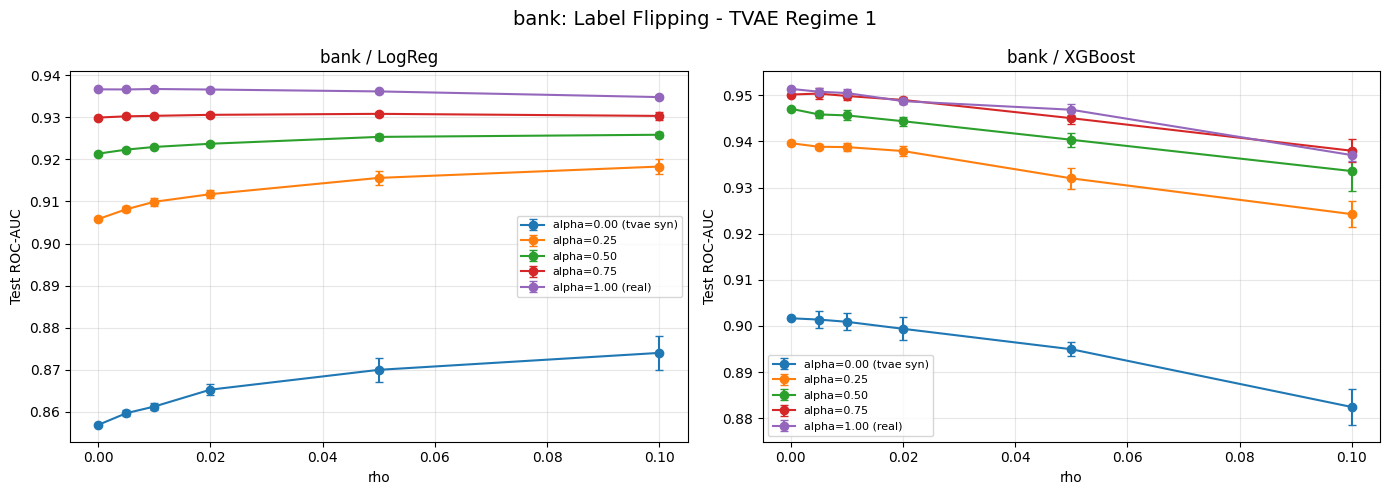

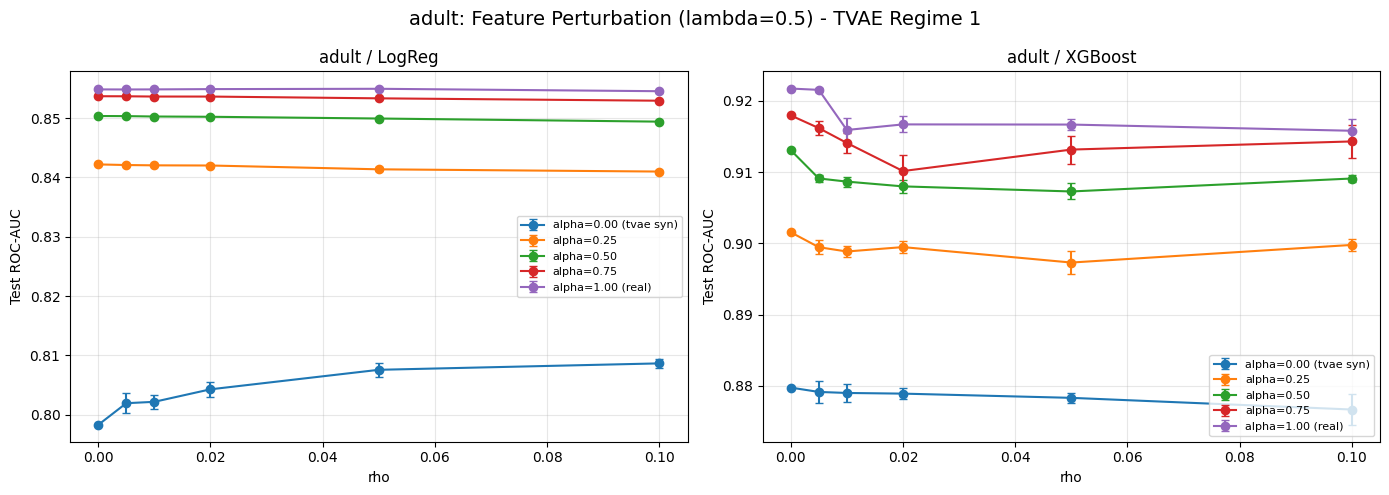

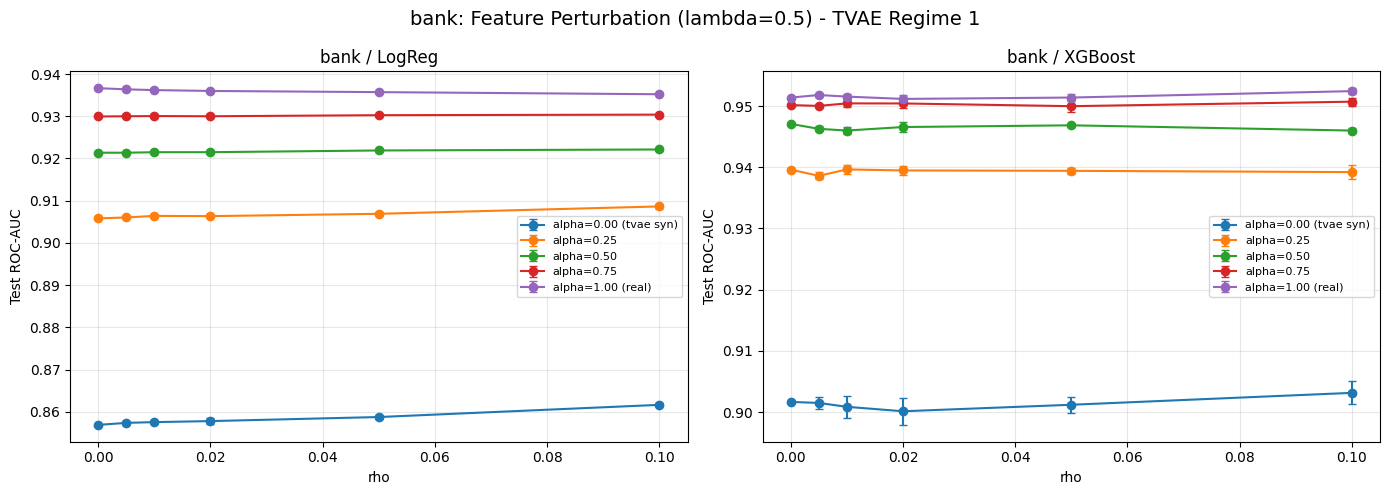

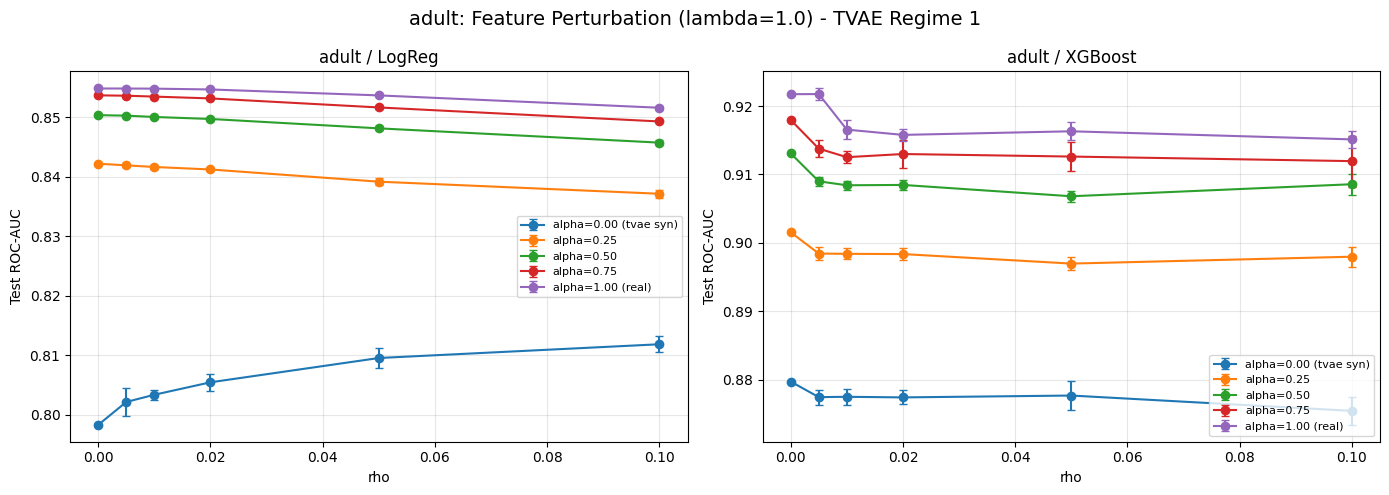

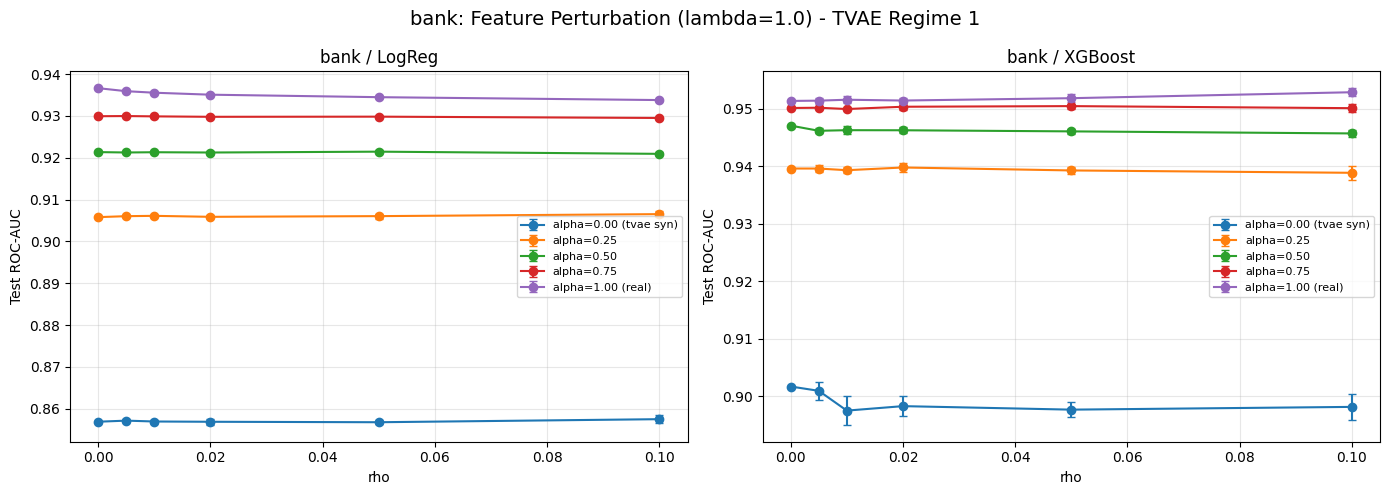

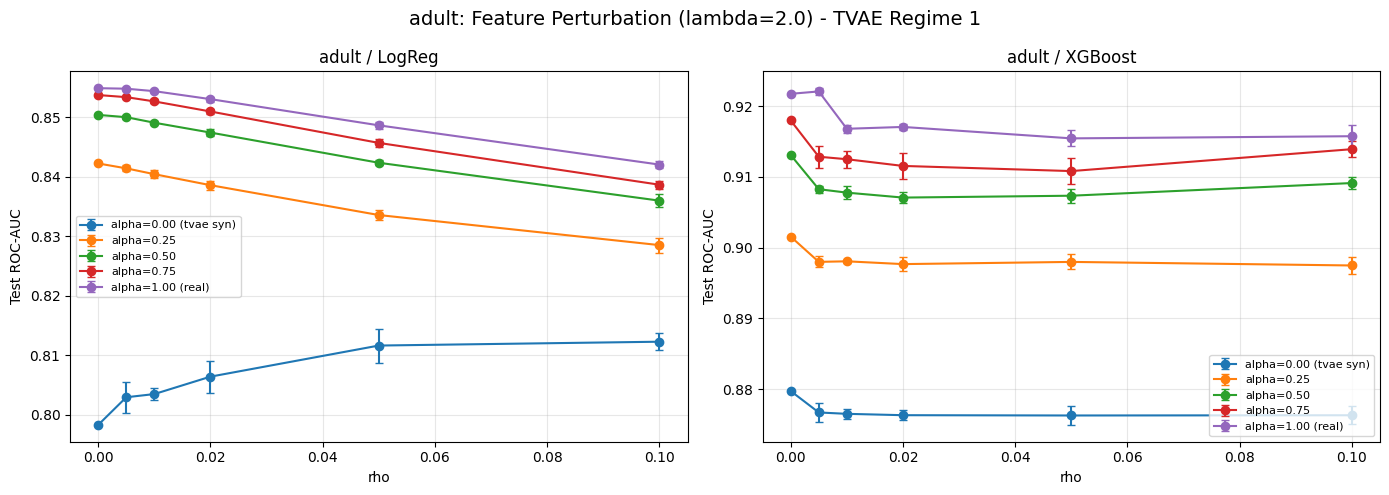

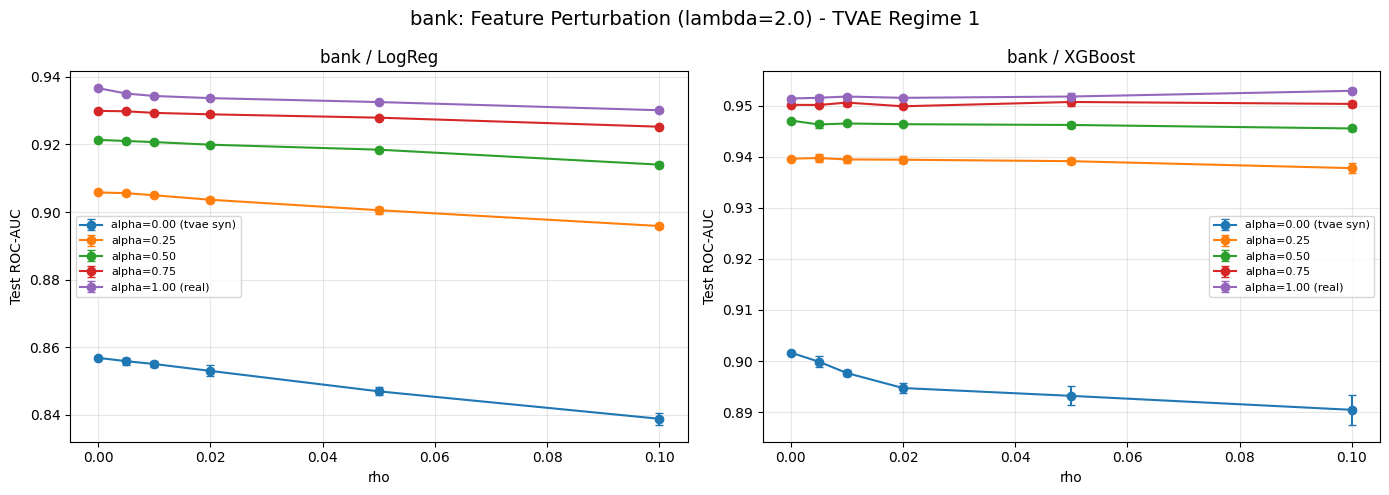

In [ ]:
def plot_degradation(df, attack_name, models=CORE_MODELS, lam_filter=None):
    for name in df['dataset'].unique():
        ds = df[df['dataset'] == name]
        if lam_filter is not None and 'lambda' in df.columns:
            ds = ds[(ds['lambda'] == lam_filter) | (ds['rho'] == 0.0)].copy()
            ds.loc[ds['rho'] == 0.0, 'lambda'] = lam_filter

        fig, axes = plt.subplots(1, len(models), figsize=(7*len(models), 5))
        if len(models) == 1: axes = [axes]

        for j, mname in enumerate(models):
            ms = ds[ds['model'] == mname]
            for alpha in ALPHAS:
                sub = ms[ms['alpha'] == alpha].groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                label = f'alpha={alpha:.2f}'
                if alpha == 1.0: label += ' (real)'
                elif alpha == 0.0: label += ' (tvae syn)'
                axes[j].errorbar(sub['rho'], sub['mean'], yerr=sub['std'],
                                 marker='o', capsize=3, label=label)
            axes[j].set_xlabel('rho')
            axes[j].set_ylabel('Test ROC-AUC')
            axes[j].set_title(f'{name} / {mname}')
            axes[j].legend(fontsize=8)
            axes[j].grid(True, alpha=0.3)

        suffix = f' (lambda={lam_filter})' if lam_filter else ''
        plt.suptitle(f'{name}: {attack_name}{suffix} - TVAE Regime 1', fontsize=14)
        plt.tight_layout()
        fname_suffix = f'_lam{lam_filter}' if lam_filter else ''
        plt.savefig(f'figures/tvae/{name}_{attack_name.lower().replace(" ","_")}{fname_suffix}_r1_tvae.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

plot_degradation(lf_r1_tvae, 'Label Flipping')
for lam in LAMBDAS:
    plot_degradation(fp_r1_tvae, 'Feature Perturbation', lam_filter=lam)

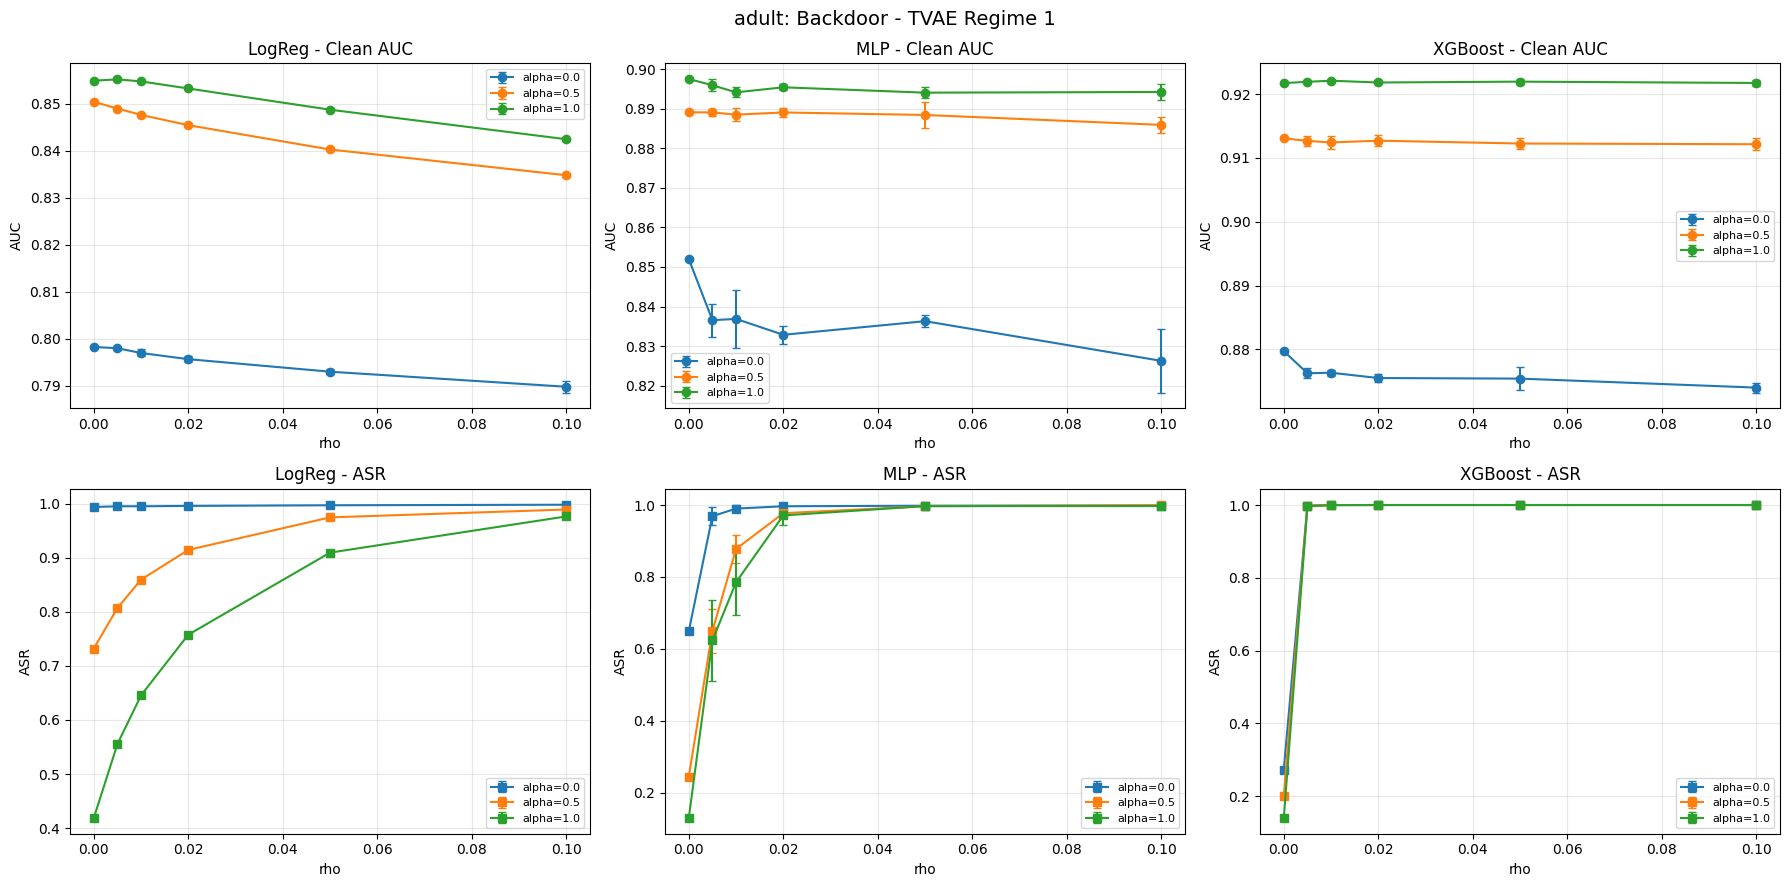

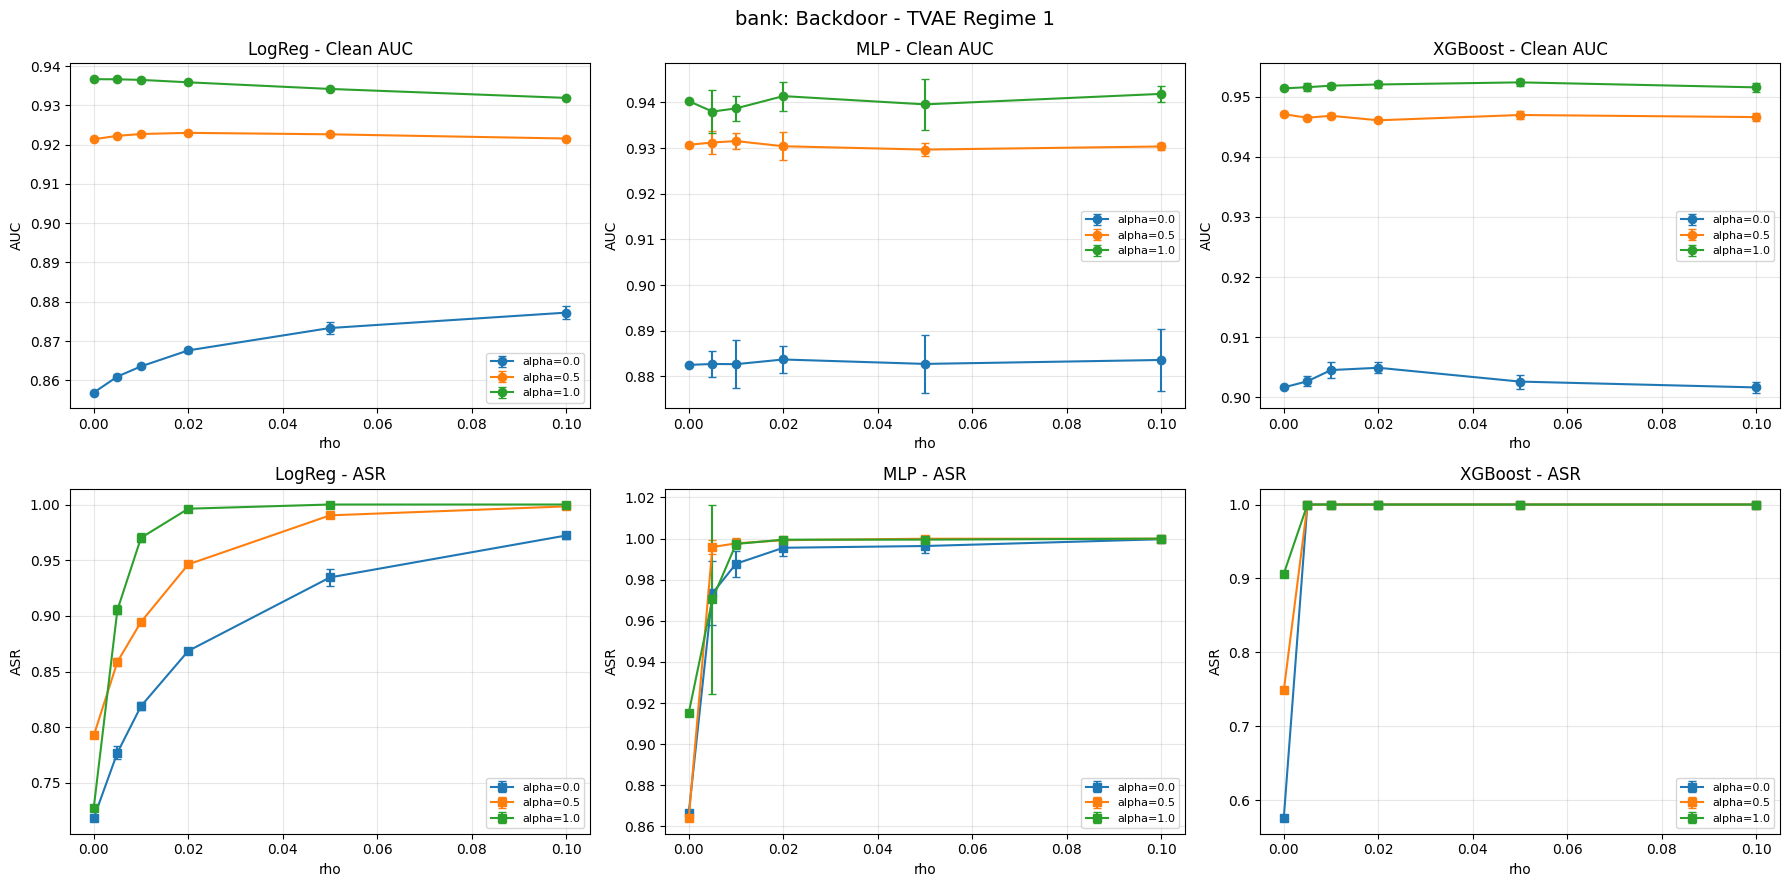

In [13]:
# BD curves with AUC and ASR
def plot_bd_curves(df, title_suffix=''):
    for name in df['dataset'].unique():
        ds = df[df['dataset'] == name]
        models_present = sorted(ds['model'].unique())

        fig, axes = plt.subplots(2, len(models_present), figsize=(6*len(models_present), 9))
        if len(models_present) == 1: axes = axes.reshape(-1, 1)

        for j, mname in enumerate(models_present):
            ms = ds[ds['model'] == mname]
            for alpha in [0.0, 0.5, 1.0]:
                auc_agg = ms[ms['alpha']==alpha].groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                axes[0, j].errorbar(auc_agg['rho'], auc_agg['mean'], yerr=auc_agg['std'],
                                    marker='o', capsize=3, label=f'alpha={alpha:.1f}')
                asr_agg = ms[ms['alpha']==alpha].groupby('rho')['asr'].agg(['mean','std']).reset_index()
                axes[1, j].errorbar(asr_agg['rho'], asr_agg['mean'], yerr=asr_agg['std'],
                                    marker='s', capsize=3, label=f'alpha={alpha:.1f}')
            axes[0, j].set_title(f'{mname} - Clean AUC')
            axes[0, j].set_xlabel('rho'); axes[0, j].set_ylabel('AUC')
            axes[0, j].legend(fontsize=8); axes[0, j].grid(True, alpha=0.3)
            axes[1, j].set_title(f'{mname} - ASR')
            axes[1, j].set_xlabel('rho'); axes[1, j].set_ylabel('ASR')
            axes[1, j].legend(fontsize=8); axes[1, j].grid(True, alpha=0.3)

        plt.suptitle(f'{name}: Backdoor - {title_suffix}', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'figures/tvae/{name}_bd_r1_tvae.png', dpi=150, bbox_inches='tight')
        plt.show()

plot_bd_curves(bd_r1_tvae, 'TVAE Regime 1')

## 11. Режим 2 - функции инъекции синтетических точек

Сэмплируем свежие точки из TVAE-генератора и инжектируем их в обучающую выборку.

In [15]:
from sdv.single_table import TVAESynthesizer

# Load all TVAE generators into DS_STATE
for name in DATASETS:
    pkl_path = f'data/synthetic/{name}_tvae.pkl'
    DS_STATE[name]['tvae'] = TVAESynthesizer.load(pkl_path)
    print(f'[{name}] TVAE loaded')


def encode_syn_df(syn_df, meta, scaler, label_encoders):
    df = syn_df.copy()
    target_col = meta['target_col']

    for c in meta['cat_cols']:
        if c in df.columns:
            if c in label_encoders:
                le = label_encoders[c]
                mask = df[c].isin(le.classes_)
                if not mask.all():
                    df.loc[~mask, c] = le.classes_[0]
                df[c] = le.transform(df[c])
            else:
                df[c] = pd.Categorical(df[c]).codes
            df[c] = df[c].astype(int)

    y = df[target_col].values.astype(int) if target_col in df.columns else None
    cols_to_use = [c for c in meta['feature_names'] if c in df.columns]
    X = df[cols_to_use].values.astype(float)

    if len(meta['num_idx']) > 0:
        X[:, meta['num_idx']] = scaler.transform(X[:, meta['num_idx']])
    return X, y


def sample_tvae_poison(name, n_poison, seed, ds_state):
    syn_fresh = ds_state['tvae'].sample(num_rows=n_poison + 50)
    syn_fresh = syn_fresh.sample(n=min(n_poison, len(syn_fresh)), random_state=seed)
    X_p, y_p = encode_syn_df(syn_fresh, ds_state['meta'], ds_state['scaler'],
                             ds_state['label_encoders'])
    if y_p is None:
        y_p = np.zeros(n_poison, dtype=int)
    return X_p[:n_poison], y_p[:n_poison]


def inject_poison(X_clean, y_clean, X_poison, y_poison, rho, seed):
    rng = np.random.RandomState(seed)
    n = len(X_clean)
    n_poison = len(X_poison)
    remove_idx = rng.choice(n, size=n_poison, replace=False)
    keep_mask = np.ones(n, dtype=bool)
    keep_mask[remove_idx] = False
    X_combined = np.vstack([X_clean[keep_mask], X_poison])
    y_combined = np.concatenate([y_clean[keep_mask], y_poison])
    shuffle_idx = rng.permutation(len(X_combined))
    return X_combined[shuffle_idx], y_combined[shuffle_idx]

print('Regime 2 sampling functions defined.')

[adult] TVAE loaded
[bank] TVAE loaded
Regime 2 sampling functions defined.


## 12. Режим 2 - LF (label-flipped TVAE-инъекция)

In [ ]:
def lf_r2_one_seed(seed, alpha, rho, X_train, y_train,
                   X_poison, y_poison, X_test, y_test, name):
    if rho == 0.0 or X_poison is None:
        X_tr, y_tr = X_train.copy(), y_train.copy()
    else:
        y_p_flipped = 1 - y_poison
        X_tr, y_tr = inject_poison(X_train, y_train, X_poison, y_p_flipped, rho, seed)
    rows = []
    for mname, model in get_core_models().items():
        model.fit(X_tr, y_tr)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        rows.append({'dataset': name, 'generator': 'TVAE', 'regime': 'R2',
                     'alpha': alpha, 'attack': 'LF-R2', 'rho': rho,
                     'seed': seed, 'model': mname, 'test_auc': auc})
    return rows

def run_lf_r2_tvae(name):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    all_results = []
    for alpha in ALPHAS:
        tag = f'alpha_{alpha:.2f}_tvae'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')
        n_train = len(X_train)

        for rho in [0.0] + POISON_RATES:
            n_poison = int(rho * n_train)

            # Pre-sample on GPU (sequential)
            poison_by_seed = {}
            for seed in SEEDS:
                if n_poison > 0:
                    poison_by_seed[seed] = sample_tvae_poison(name, n_poison, seed, DS_STATE[name])
                else:
                    poison_by_seed[seed] = (None, None)

            # Parallel training (CPU)
            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(lf_r2_one_seed)(
                    seed, alpha, rho, X_train, y_train,
                    poison_by_seed[seed][0], poison_by_seed[seed][1],
                    X_test, y_test, name)
                for seed in SEEDS)
            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] LF-R2 alpha={alpha:.2f} rho={rho:.3f} done')

    return pd.DataFrame(all_results)

lf_r2_frames = []
for ds_name in DATASETS:
    print(f'{ds_name}: LF Regime 2 (TVAE)')
    lf_r2_frames.append(run_lf_r2_tvae(ds_name))

lf_r2_tvae = pd.concat(lf_r2_frames, ignore_index=True)
lf_r2_tvae.to_csv('results/tvae/lf_r2_tvae.csv', index=False)
print(f'Saved {len(lf_r2_tvae)} rows')

adult: LF Regime 2 (TVAE)
  [adult] LF-R2 alpha=0.00 rho=0.000 done
  [adult] LF-R2 alpha=0.00 rho=0.005 done
  [adult] LF-R2 alpha=0.00 rho=0.010 done
  [adult] LF-R2 alpha=0.00 rho=0.020 done
  [adult] LF-R2 alpha=0.00 rho=0.050 done
  [adult] LF-R2 alpha=0.00 rho=0.100 done
  [adult] LF-R2 alpha=0.25 rho=0.000 done
  [adult] LF-R2 alpha=0.25 rho=0.005 done
  [adult] LF-R2 alpha=0.25 rho=0.010 done
  [adult] LF-R2 alpha=0.25 rho=0.020 done
  [adult] LF-R2 alpha=0.25 rho=0.050 done
  [adult] LF-R2 alpha=0.25 rho=0.100 done
  [adult] LF-R2 alpha=0.50 rho=0.000 done
  [adult] LF-R2 alpha=0.50 rho=0.005 done
  [adult] LF-R2 alpha=0.50 rho=0.010 done
  [adult] LF-R2 alpha=0.50 rho=0.020 done
  [adult] LF-R2 alpha=0.50 rho=0.050 done
  [adult] LF-R2 alpha=0.50 rho=0.100 done
  [adult] LF-R2 alpha=0.75 rho=0.000 done
  [adult] LF-R2 alpha=0.75 rho=0.005 done
  [adult] LF-R2 alpha=0.75 rho=0.010 done
  [adult] LF-R2 alpha=0.75 rho=0.020 done
  [adult] LF-R2 alpha=0.75 rho=0.050 done
  [adult

## 13. Режим 2 - FP (TVAE-инъекция с изменением признаков)

In [ ]:
def fp_r2_one_seed(seed, alpha, rho, lam, X_train, y_train,
                   X_poison_raw, y_poison_raw, meta, X_test, y_test, name):
    if rho == 0.0 or X_poison_raw is None:
        X_tr, y_tr = X_train.copy(), y_train.copy()
    else:
        X_p = X_poison_raw.copy()
        rng = np.random.RandomState(seed)
        if len(meta['num_idx']) > 0:
            noise = rng.normal(0, lam, size=(len(X_p), len(meta['num_idx'])))
            X_p[:, meta['num_idx']] += noise
        if len(meta['cat_idx']) > 0:
            for i in range(len(X_p)):
                col = rng.choice(meta['cat_idx'])
                vals = np.unique(X_train[:, col])
                X_p[i, col] = rng.choice(vals)
        X_tr, y_tr = inject_poison(X_train, y_train, X_p, y_poison_raw, rho, seed)

    rows = []
    for mname, model in get_core_models().items():
        model.fit(X_tr, y_tr)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        rows.append({'dataset': name, 'generator': 'TVAE', 'regime': 'R2',
                     'alpha': alpha, 'attack': 'FP-R2', 'rho': rho,
                     'lambda': lam, 'seed': seed,
                     'model': mname, 'test_auc': auc})
    return rows

def run_fp_r2_tvae(name):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    all_results = []
    for alpha in ALPHAS:
        tag = f'alpha_{alpha:.2f}_tvae'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')
        n_train = len(X_train)

        for rho in [0.0] + POISON_RATES:
            n_poison = int(rho * n_train)

            # Pre-sample
            poison_by_seed = {}
            for seed in SEEDS:
                if n_poison > 0:
                    poison_by_seed[seed] = sample_tvae_poison(name, n_poison, seed, DS_STATE[name])
                else:
                    poison_by_seed[seed] = (None, None)

            for lam in (LAMBDAS if rho > 0 else [0.0]):
                seed_results = Parallel(n_jobs=-1, verbose=0)(
                    delayed(fp_r2_one_seed)(
                        seed, alpha, rho, lam, X_train, y_train,
                        poison_by_seed[seed][0], poison_by_seed[seed][1],
                        meta, X_test, y_test, name)
                    for seed in SEEDS)
                for rows in seed_results:
                    all_results.extend(rows)
                print(f'  [{name}] FP-R2 alpha={alpha:.2f} rho={rho:.3f} lambda={lam} done')

    return pd.DataFrame(all_results)

fp_r2_frames = []
for ds_name in DATASETS:
    print(f'{ds_name}: FP Regime 2 (TVAE)')
    fp_r2_frames.append(run_fp_r2_tvae(ds_name))

fp_r2_tvae = pd.concat(fp_r2_frames, ignore_index=True)
fp_r2_tvae.to_csv('results/tvae/fp_r2_tvae.csv', index=False)
print(f'Saved {len(fp_r2_tvae)} rows')

adult: FP Regime 2 (TVAE)
  [adult] FP-R2 alpha=0.00 rho=0.000 lambda=0.0 done
  [adult] FP-R2 alpha=0.00 rho=0.005 lambda=0.5 done
  [adult] FP-R2 alpha=0.00 rho=0.005 lambda=1.0 done
  [adult] FP-R2 alpha=0.00 rho=0.005 lambda=2.0 done
  [adult] FP-R2 alpha=0.00 rho=0.010 lambda=0.5 done
  [adult] FP-R2 alpha=0.00 rho=0.010 lambda=1.0 done
  [adult] FP-R2 alpha=0.00 rho=0.010 lambda=2.0 done
  [adult] FP-R2 alpha=0.00 rho=0.020 lambda=0.5 done
  [adult] FP-R2 alpha=0.00 rho=0.020 lambda=1.0 done
  [adult] FP-R2 alpha=0.00 rho=0.020 lambda=2.0 done
  [adult] FP-R2 alpha=0.00 rho=0.050 lambda=0.5 done
  [adult] FP-R2 alpha=0.00 rho=0.050 lambda=1.0 done
  [adult] FP-R2 alpha=0.00 rho=0.050 lambda=2.0 done
  [adult] FP-R2 alpha=0.00 rho=0.100 lambda=0.5 done
  [adult] FP-R2 alpha=0.00 rho=0.100 lambda=1.0 done
  [adult] FP-R2 alpha=0.00 rho=0.100 lambda=2.0 done
  [adult] FP-R2 alpha=0.25 rho=0.000 lambda=0.0 done
  [adult] FP-R2 alpha=0.25 rho=0.005 lambda=0.5 done
  [adult] FP-R2 alph

## 14. Режим 2 - BD (TVAE-инъекция с триггером)

In [16]:
def compute_asr_metrics(model, X_test, y_test, X_test_trig, target_label):
    preds_trig = model.predict(X_test_trig)
    asr_full = (preds_trig == target_label).mean()
    nontarget_mask = (y_test != target_label)
    if nontarget_mask.sum() > 0:
        asr_nontarget = (preds_trig[nontarget_mask] == target_label).mean()
    else:
        asr_nontarget = float('nan')
    return asr_full, asr_nontarget


def bd_r2_one_seed(seed, alpha, rho, X_train, y_train, X_poison_raw,
                   trigger_cols, trigger_vals, target_label,
                   X_test, X_test_trig, y_test, name):
    if rho == 0.0 or X_poison_raw is None:
        X_tr, y_tr = X_train.copy(), y_train.copy()
    else:
        X_p_trig = apply_trigger(X_poison_raw, trigger_cols, trigger_vals)
        y_p_target = np.full(len(X_p_trig), target_label, dtype=int)
        X_tr, y_tr = inject_poison(X_train, y_train, X_p_trig, y_p_target, rho, seed)

    rows = []
    for mname, model in get_all_models().items():
        model.fit(X_tr, y_tr)
        auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        asr_full, asr_nontarget = compute_asr_metrics(
            model, X_test, y_test, X_test_trig, target_label)
        rows.append({'dataset': name, 'generator': 'TVAE', 'regime': 'R2',
                     'alpha': alpha, 'attack': 'BD-R2', 'rho': rho,
                     'seed': seed, 'model': mname,
                     'test_auc': auc,
                     'asr': asr_full,
                     'asr_nontarget': asr_nontarget})
    return rows

def run_bd_r2_tvae(name, target_label=1):
    ds_state = DS_STATE[name]
    meta = ds_state['meta']
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')

    trigger_cols = meta['num_idx'][:2] if len(meta['num_idx']) >= 2 else meta['num_idx']
    trigger_vals = [3.0] * len(trigger_cols)
    X_test_trig = apply_trigger(X_test, trigger_cols, trigger_vals)

    all_results = []
    for alpha in [0.0, 0.5, 1.0]:
        tag = f'alpha_{alpha:.2f}_tvae'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')
        n_train = len(X_train)

        for rho in [0.0] + POISON_RATES:
            n_poison = int(rho * n_train)
            poison_by_seed = {}
            for seed in SEEDS:
                if n_poison > 0:
                    X_p_raw, _ = sample_tvae_poison(name, n_poison, seed, ds_state)
                    poison_by_seed[seed] = X_p_raw
                else:
                    poison_by_seed[seed] = None

            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(bd_r2_one_seed)(
                    seed, alpha, rho, X_train, y_train, poison_by_seed[seed],
                    trigger_cols, trigger_vals, target_label,
                    X_test, X_test_trig, y_test, name)
                for seed in SEEDS)
            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] BD-R2 alpha={alpha:.2f} rho={rho:.3f} done')

    df = pd.DataFrame(all_results)

    df['asr_delta'] = float('nan')
    df['asr_nontarget_delta'] = float('nan')
    for (ds, a, m), sub in df.groupby(['dataset', 'alpha', 'model']):
        clean_full = sub.loc[sub['rho'] == 0.0, 'asr'].mean()
        clean_nt   = sub.loc[sub['rho'] == 0.0, 'asr_nontarget'].mean()
        mask = (df['dataset'] == ds) & (df['alpha'] == a) & (df['model'] == m)
        df.loc[mask, 'asr_delta']           = df.loc[mask, 'asr'] - clean_full
        df.loc[mask, 'asr_nontarget_delta'] = df.loc[mask, 'asr_nontarget'] - clean_nt

    return df

bd_r2_frames = []
for ds_name in DATASETS:
    print(f'{ds_name}: BD Regime 2 (TVAE)')
    bd_r2_frames.append(run_bd_r2_tvae(ds_name))

bd_r2_tvae = pd.concat(bd_r2_frames, ignore_index=True)
bd_r2_tvae.to_csv('results/tvae/bd_r2_tvae.csv', index=False)
print(f'Saved {len(bd_r2_tvae)} rows')

adult: BD Regime 2 (TVAE)
  [adult] BD-R2 alpha=0.00 rho=0.000 done
  [adult] BD-R2 alpha=0.00 rho=0.005 done
  [adult] BD-R2 alpha=0.00 rho=0.010 done
  [adult] BD-R2 alpha=0.00 rho=0.020 done
  [adult] BD-R2 alpha=0.00 rho=0.050 done
  [adult] BD-R2 alpha=0.00 rho=0.100 done
  [adult] BD-R2 alpha=0.50 rho=0.000 done
  [adult] BD-R2 alpha=0.50 rho=0.005 done
  [adult] BD-R2 alpha=0.50 rho=0.010 done
  [adult] BD-R2 alpha=0.50 rho=0.020 done
  [adult] BD-R2 alpha=0.50 rho=0.050 done
  [adult] BD-R2 alpha=0.50 rho=0.100 done
  [adult] BD-R2 alpha=1.00 rho=0.000 done
  [adult] BD-R2 alpha=1.00 rho=0.005 done
  [adult] BD-R2 alpha=1.00 rho=0.010 done
  [adult] BD-R2 alpha=1.00 rho=0.020 done
  [adult] BD-R2 alpha=1.00 rho=0.050 done
  [adult] BD-R2 alpha=1.00 rho=0.100 done
bank: BD Regime 2 (TVAE)
  [bank] BD-R2 alpha=0.00 rho=0.000 done
  [bank] BD-R2 alpha=0.00 rho=0.005 done
  [bank] BD-R2 alpha=0.00 rho=0.010 done
  [bank] BD-R2 alpha=0.00 rho=0.020 done
  [bank] BD-R2 alpha=0.00 rho

## 15. Защиты на TVAE-данных

Тестируем sanitization, cleanlab и spectral filtering - на Adult.

In [ ]:
from sklearn.covariance import EllipticEnvelope

def sanitize(X, y, contamination=0.05, seed=SEED):
    try:
        detector = EllipticEnvelope(contamination=contamination, random_state=seed)
        preds = detector.fit_predict(X)
        mask = preds == 1
    except Exception:
        mask = np.ones(len(X), dtype=bool)
    return X[mask], y[mask], mask

def lf_attack_wrap(X, y, rho, meta, seed):
    if rho == 0.0: return X.copy(), y.copy(), np.array([])
    y_p, idx = label_flip(y, rho, seed)
    return X.copy(), y_p, idx

def fp_attack_wrap(X, y, rho, meta, seed):
    if rho == 0.0: return X.copy(), y.copy(), np.array([])
    X_p, idx = feature_perturb(X, y, rho, 1.0, meta, seed)
    return X_p, y.copy(), idx

def sanitize_def(X, y, seed=SEED):
    return sanitize(X, y, contamination=0.05, seed=seed)

def defense_one_seed(seed, alpha, rho, X_train, y_train, meta,
                     attack_fn, attack_name, defense_fn, defense_name,
                     X_test, y_test, name):
    X_atk, y_atk, _ = attack_fn(X_train, y_train, rho, meta, seed)
    rows = []
    for defended in [False, True]:
        if defended:
            X_tr, y_tr, _ = defense_fn(X_atk, y_atk, seed=seed)
        else:
            X_tr, y_tr = X_atk, y_atk
        for mname, model in get_core_models().items():
            model.fit(X_tr, y_tr)
            auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
            rows.append({'dataset': name, 'generator': 'TVAE',
                         'alpha': alpha, 'attack': attack_name,
                         'defense': defense_name if defended else 'none',
                         'rho': rho, 'seed': seed, 'model': mname,
                         'test_auc': auc})
    return rows

def run_defense_tvae(name, attack_fn, attack_name, defense_fn, defense_name):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    all_results = []
    for alpha in [0.0, 0.5, 1.0]:
        tag = f'alpha_{alpha:.2f}_tvae'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for rho in [0.0, 0.02, 0.05, 0.10]:
            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(defense_one_seed)(
                    seed, alpha, rho, X_train, y_train, meta,
                    attack_fn, attack_name, defense_fn, defense_name,
                    X_test, y_test, name)
                for seed in SEEDS)
            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] {attack_name}+{defense_name} alpha={alpha:.2f} rho={rho:.3f} done')
    return pd.DataFrame(all_results)

san_results = []
san_results.append(run_defense_tvae('adult', lf_attack_wrap, 'LF', sanitize_def, 'sanitize'))
san_results.append(run_defense_tvae('adult', fp_attack_wrap, 'FP', sanitize_def, 'sanitize'))
san_tvae = pd.concat(san_results, ignore_index=True)
san_tvae.to_csv('results/tvae/defense_sanitize_tvae.csv', index=False)
print(f'Sanitize saved: {len(san_tvae)} rows')

  [adult] LF+sanitize alpha=0.00 rho=0.000 done
  [adult] LF+sanitize alpha=0.00 rho=0.020 done
  [adult] LF+sanitize alpha=0.00 rho=0.050 done
  [adult] LF+sanitize alpha=0.00 rho=0.100 done
  [adult] LF+sanitize alpha=0.50 rho=0.000 done
  [adult] LF+sanitize alpha=0.50 rho=0.020 done
  [adult] LF+sanitize alpha=0.50 rho=0.050 done
  [adult] LF+sanitize alpha=0.50 rho=0.100 done
  [adult] LF+sanitize alpha=1.00 rho=0.000 done
  [adult] LF+sanitize alpha=1.00 rho=0.020 done
  [adult] LF+sanitize alpha=1.00 rho=0.050 done
  [adult] LF+sanitize alpha=1.00 rho=0.100 done
  [adult] FP+sanitize alpha=0.00 rho=0.000 done
  [adult] FP+sanitize alpha=0.00 rho=0.020 done
  [adult] FP+sanitize alpha=0.00 rho=0.050 done
  [adult] FP+sanitize alpha=0.00 rho=0.100 done
  [adult] FP+sanitize alpha=0.50 rho=0.000 done
  [adult] FP+sanitize alpha=0.50 rho=0.020 done
  [adult] FP+sanitize alpha=0.50 rho=0.050 done
  [adult] FP+sanitize alpha=0.50 rho=0.100 done
  [adult] FP+sanitize alpha=1.00 rho=0.0

In [ ]:
try:
    from cleanlab.filter import find_label_issues
    from sklearn.model_selection import cross_val_predict

    def cleanlab_def(X, y, seed=SEED):
        try:
            lr = LogisticRegression(max_iter=1000, random_state=seed)
            pred_probs = cross_val_predict(lr, X, y, cv=3, method='predict_proba')
            issue_idx = find_label_issues(y, pred_probs, return_indices_ranked_by='self_confidence')
            n_remove = min(len(issue_idx), int(0.1 * len(y)))
            remove_set = set(issue_idx[:n_remove])
            mask = np.array([i not in remove_set for i in range(len(y))])
        except Exception as e:
            print(f'  cleanlab failed: {e}')
            mask = np.ones(len(y), dtype=bool)
        return X[mask], y[mask], mask

    cl_tvae = run_defense_tvae('adult', lf_attack_wrap, 'LF', cleanlab_def, 'cleanlab')
    cl_tvae.to_csv('results/tvae/defense_cleanlab_tvae.csv', index=False)
    print(f'Cleanlab saved: {len(cl_tvae)} rows')
except ImportError:
    print('cleanlab not installed, skipping')
    cl_tvae = pd.DataFrame()

  [adult] LF+cleanlab alpha=0.00 rho=0.000 done
  [adult] LF+cleanlab alpha=0.00 rho=0.020 done
  [adult] LF+cleanlab alpha=0.00 rho=0.050 done
  [adult] LF+cleanlab alpha=0.00 rho=0.100 done
  [adult] LF+cleanlab alpha=0.50 rho=0.000 done
  [adult] LF+cleanlab alpha=0.50 rho=0.020 done
  [adult] LF+cleanlab alpha=0.50 rho=0.050 done
  [adult] LF+cleanlab alpha=0.50 rho=0.100 done
  [adult] LF+cleanlab alpha=1.00 rho=0.000 done
  [adult] LF+cleanlab alpha=1.00 rho=0.020 done
  [adult] LF+cleanlab alpha=1.00 rho=0.050 done
  [adult] LF+cleanlab alpha=1.00 rho=0.100 done
Cleanlab saved: 240 rows


In [ ]:
def get_mlp_representations(X, y, seed=SEED):
    mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                       early_stopping=True, random_state=seed, verbose=False)
    mlp.fit(X, y)
    activations = X.copy()
    penultimate = None
    for i, (W, b) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
        activations = activations @ W + b
        if i < len(mlp.coefs_) - 1:
            activations = np.maximum(activations, 0)
        if i == len(mlp.coefs_) - 2:
            penultimate = activations.copy()
            break
    return mlp, penultimate

def spectral_filter(X, y, penultimate, top_k_pct=0.05):
    centered = penultimate - penultimate.mean(axis=0)
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    top_v = Vt[0]
    scores = np.abs(centered @ top_v)
    n_remove = int(top_k_pct * len(X))
    threshold = np.sort(scores)[-n_remove] if n_remove > 0 else np.inf
    mask = scores < threshold
    return X[mask], y[mask], mask, scores

def spectral_one_seed(seed, alpha, rho, X_train, y_train, meta,
                      trigger_cols, trigger_vals,
                      X_test, X_test_trig, y_test, name):
    if rho == 0.0:
        X_tr, y_tr = X_train.copy(), y_train.copy()
    else:
        X_tr, y_tr, _, _, _ = backdoor_poison(X_train, y_train, rho, meta, seed=seed)

    rows = []
    for defended in [False, True]:
        if defended:
            _, penult = get_mlp_representations(X_tr, y_tr, seed)
            X_d, y_d, _, _ = spectral_filter(X_tr, y_tr, penult)
        else:
            X_d, y_d = X_tr, y_tr

        mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                            early_stopping=True, random_state=seed, verbose=False)
        mlp.fit(X_d, y_d)
        auc = roc_auc_score(y_test, mlp.predict_proba(X_test)[:, 1])
        asr = (mlp.predict(X_test_trig) == 1).mean()
        rows.append({'dataset': name, 'generator': 'TVAE',
                     'alpha': alpha, 'attack': 'BD',
                     'defense': 'spectral' if defended else 'none',
                     'rho': rho, 'seed': seed, 'model': 'MLP',
                     'test_auc': auc, 'asr': asr})
    return rows

def run_spectral_tvae(name):
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    y_test = np.load(f'data/processed/{name}/y_test.npy')
    with open(f'data/processed/{name}/meta.json') as f:
        meta = json.load(f)

    trigger_cols = meta['num_idx'][:2] if len(meta['num_idx']) >= 2 else meta['num_idx']
    trigger_vals = [3.0] * len(trigger_cols)
    X_test_trig = apply_trigger(X_test, trigger_cols, trigger_vals)

    all_results = []
    for alpha in [0.0, 0.5, 1.0]:
        tag = f'alpha_{alpha:.2f}_tvae'
        X_train = np.load(f'data/processed/{name}/X_train_{tag}.npy')
        y_train = np.load(f'data/processed/{name}/y_train_{tag}.npy')

        for rho in [0.0, 0.02, 0.05, 0.10]:
            seed_results = Parallel(n_jobs=-1, verbose=0)(
                delayed(spectral_one_seed)(
                    seed, alpha, rho, X_train, y_train, meta,
                    trigger_cols, trigger_vals,
                    X_test, X_test_trig, y_test, name)
                for seed in SEEDS)
            for rows in seed_results:
                all_results.extend(rows)
            print(f'  [{name}] BD+spectral alpha={alpha:.2f} rho={rho:.3f} done')
    return pd.DataFrame(all_results)

spec_tvae = run_spectral_tvae('adult')
spec_tvae.to_csv('results/tvae/defense_spectral_tvae.csv', index=False)
print(f'Spectral saved: {len(spec_tvae)} rows')

  [adult] BD+spectral alpha=0.00 rho=0.000 done
  [adult] BD+spectral alpha=0.00 rho=0.020 done
  [adult] BD+spectral alpha=0.00 rho=0.050 done
  [adult] BD+spectral alpha=0.00 rho=0.100 done
  [adult] BD+spectral alpha=0.50 rho=0.000 done
  [adult] BD+spectral alpha=0.50 rho=0.020 done
  [adult] BD+spectral alpha=0.50 rho=0.050 done
  [adult] BD+spectral alpha=0.50 rho=0.100 done
  [adult] BD+spectral alpha=1.00 rho=0.000 done
  [adult] BD+spectral alpha=1.00 rho=0.020 done
  [adult] BD+spectral alpha=1.00 rho=0.050 done
  [adult] BD+spectral alpha=1.00 rho=0.100 done
Spectral saved: 120 rows


## 16. Privacy-метрики для TVAE

MIA, DCR, NNDR для TVAE-синтетики vs реальной обучающей выборки.

In [ ]:
from sklearn.neighbors import NearestNeighbors

def compute_dcr_nndr(syn_arr, real_arr):
    nn = NearestNeighbors(n_neighbors=2, metric='euclidean').fit(real_arr)
    dists, _ = nn.kneighbors(syn_arr)
    dcr = dists[:, 0]
    nndr = dists[:, 0] / (dists[:, 1] + 1e-10)
    return dcr, nndr

def privacy_tvae(name):
    ds_state = DS_STATE[name]
    meta = ds_state['meta']
    scaler = ds_state['scaler']
    label_encoders = ds_state['label_encoders']

    X_train_real = np.load(f'data/processed/{name}/X_train_alpha_1.00.npy')
    X_test = np.load(f'data/processed/{name}/X_test.npy')
    X_syn, _ = encode_syn_to_npy(name, ds_state['target_col'], meta,
                                 label_encoders, scaler)

    dcr, nndr = compute_dcr_nndr(X_syn, X_train_real)

    nn_syn = NearestNeighbors(n_neighbors=1).fit(X_syn)
    d_members, _ = nn_syn.kneighbors(X_train_real)
    d_nonmembers, _ = nn_syn.kneighbors(X_test)
    threshold = np.median(np.concatenate([d_members.ravel(), d_nonmembers.ravel()]))
    tp = (d_members.ravel() < threshold).mean()
    fp = (d_nonmembers.ravel() < threshold).mean()
    advantage = abs(tp - fp)

    print(f'[{name}] TVAE Privacy:')
    print(f'  MIA - TP: {tp:.4f}, FP: {fp:.4f}, Advantage: {advantage:.4f}')
    print(f'  DCR  - mean: {dcr.mean():.4f}, median: {np.median(dcr):.4f}, '
          f'min: {dcr.min():.4f}, 5pctl: {np.percentile(dcr, 5):.4f}')
    print(f'  NNDR - mean: {nndr.mean():.4f}, median: {np.median(nndr):.4f}')

    return {'dataset': name, 'generator': 'TVAE',
            'mia_tp': tp, 'mia_fp': fp, 'mia_advantage': advantage,
            'dcr_mean': dcr.mean(), 'dcr_median': np.median(dcr),
            'dcr_min': dcr.min(), 'dcr_5pctl': np.percentile(dcr, 5),
            'nndr_mean': nndr.mean(), 'nndr_median': np.median(nndr)}

priv_rows = [privacy_tvae(n) for n in DATASETS]
priv_tvae = pd.DataFrame(priv_rows)
priv_tvae.to_csv('results/tvae/privacy_tvae.csv', index=False)
print(priv_tvae.to_string(index=False))

[adult] TVAE Privacy:
  MIA - TP: 0.5023, FP: 0.4932, Advantage: 0.0091
  DCR  - mean: 1.3640, median: 1.1560, min: 0.2931, 5pctl: 1.0034
  NNDR - mean: 0.9257, median: 0.9581
[bank] TVAE Privacy:
  MIA - TP: 0.5013, FP: 0.4962, Advantage: 0.0050
  DCR  - mean: 1.2832, median: 1.0858, min: 0.0038, 5pctl: 0.1959
  NNDR - mean: 0.8108, median: 0.8898
dataset generator   mia_tp   mia_fp  mia_advantage  dcr_mean  dcr_median  dcr_min  dcr_5pctl  nndr_mean  nndr_median
  adult      TVAE 0.502252 0.493168       0.009085  1.363981    1.156021 0.293055   1.003381   0.925721     0.958087
   bank      TVAE 0.501254 0.496237       0.005018  1.283150    1.085790 0.003839   0.195854   0.810817     0.889844


## 17. Сравнение TVAE vs CTGAN

Загружаем результаты основного CTGAN-бенчмарка и сравниваем по всем основным метрикам.

In [ ]:
# Load CTGAN results
def safe_read(path, default=None):
    if os.path.exists(path):
        return pd.read_csv(path)
    print(f'  [!] {path} not found')
    return default if default is not None else pd.DataFrame()

lf_r1_ctgan = safe_read('results/label_flip_all.csv')
fp_r1_ctgan = safe_read('results/feature_perturb_all.csv')
bd_r1_ctgan = safe_read('results/backdoor_all.csv')
priv_ctgan = safe_read('results/privacy_metrics.csv')

# Tag CTGAN data for merging
for df in [lf_r1_ctgan, fp_r1_ctgan, bd_r1_ctgan]:
    if len(df) > 0 and 'generator' not in df.columns:
        df['generator'] = 'CTGAN'
if len(priv_ctgan) > 0 and 'generator' not in priv_ctgan.columns:
    priv_ctgan['generator'] = 'CTGAN'

print(f'CTGAN data loaded:')
print(f'  LF R1: {len(lf_r1_ctgan)}, FP R1: {len(fp_r1_ctgan)}, '
      f'BD R1: {len(bd_r1_ctgan)}, Privacy: {len(priv_ctgan)}')

CTGAN data loaded:
  LF R1: 600, FP R1: 1600, BD R1: 270, Privacy: 2


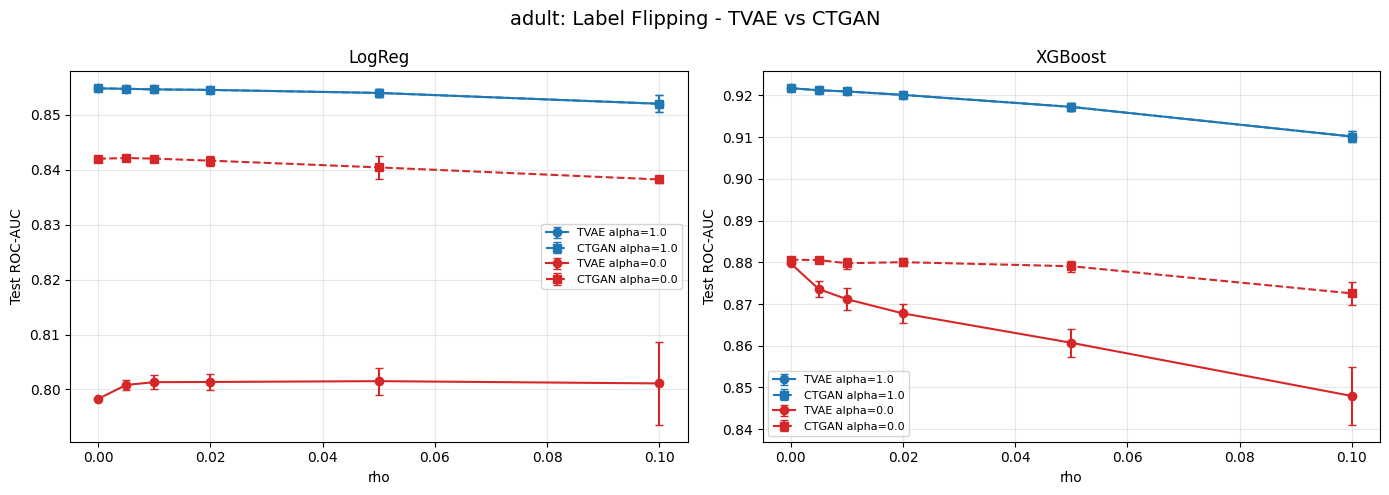

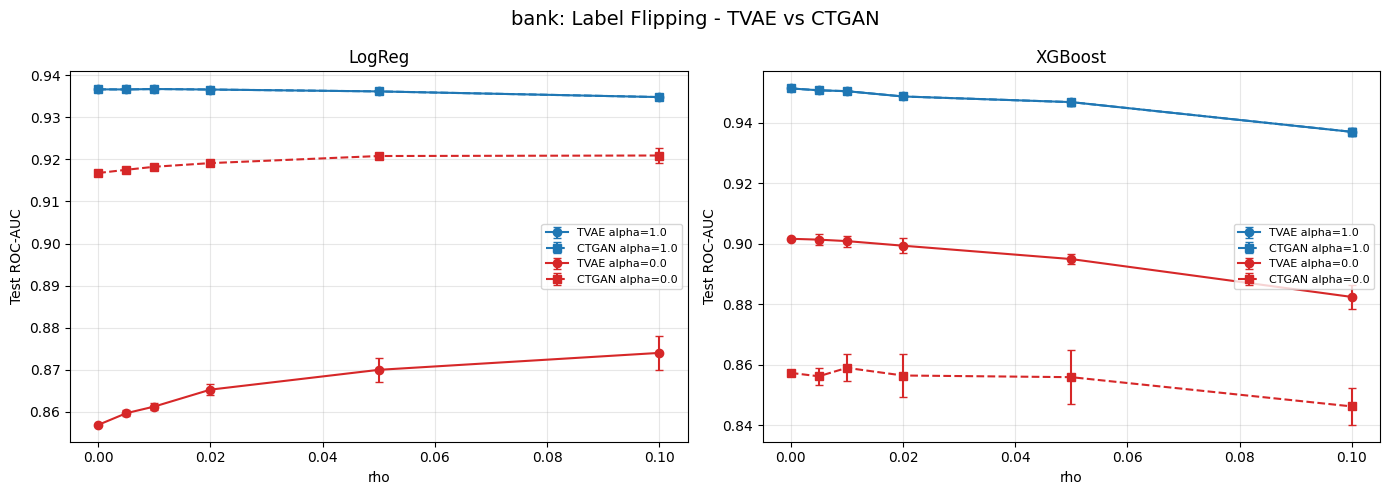

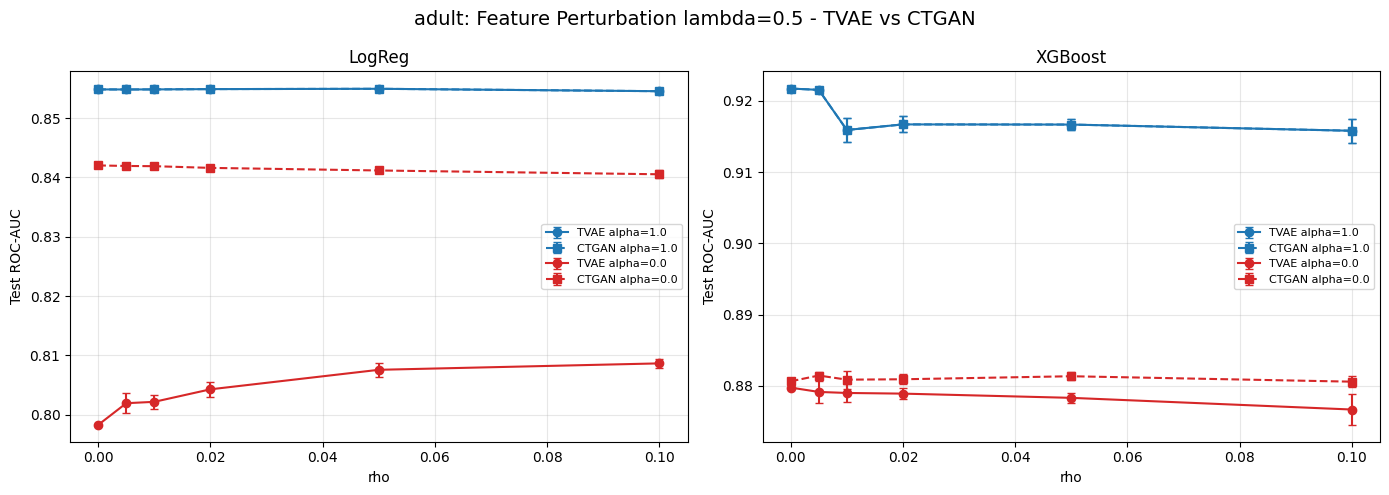

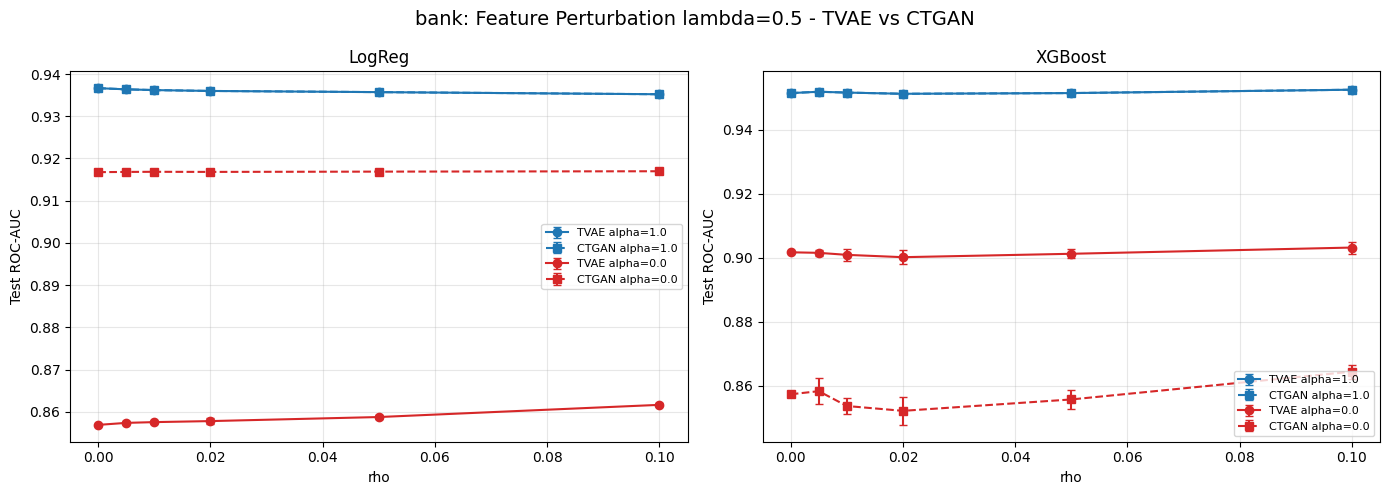

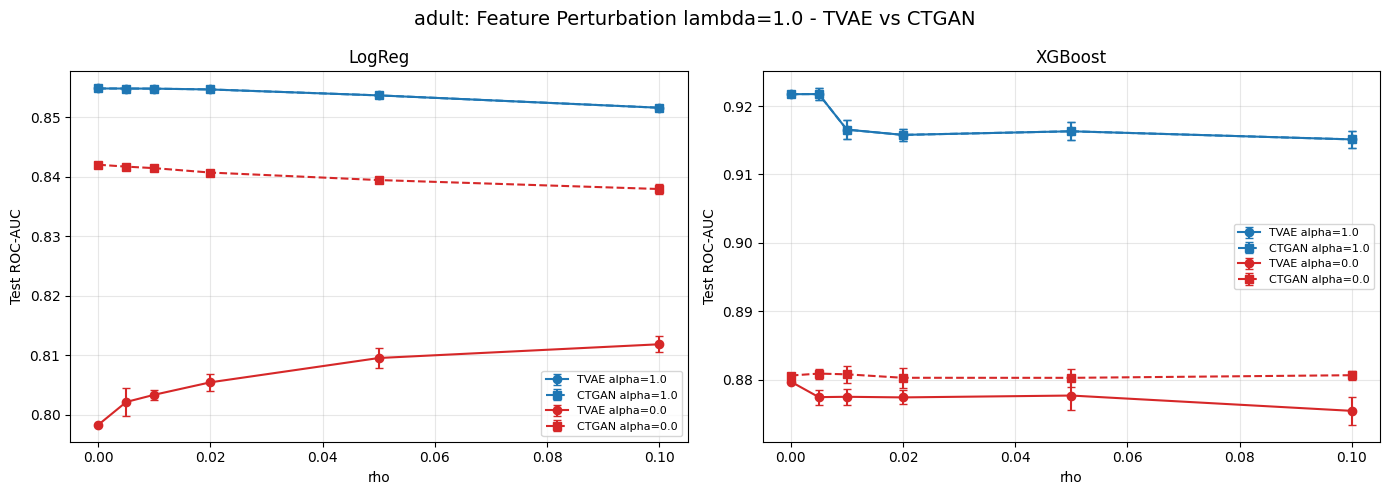

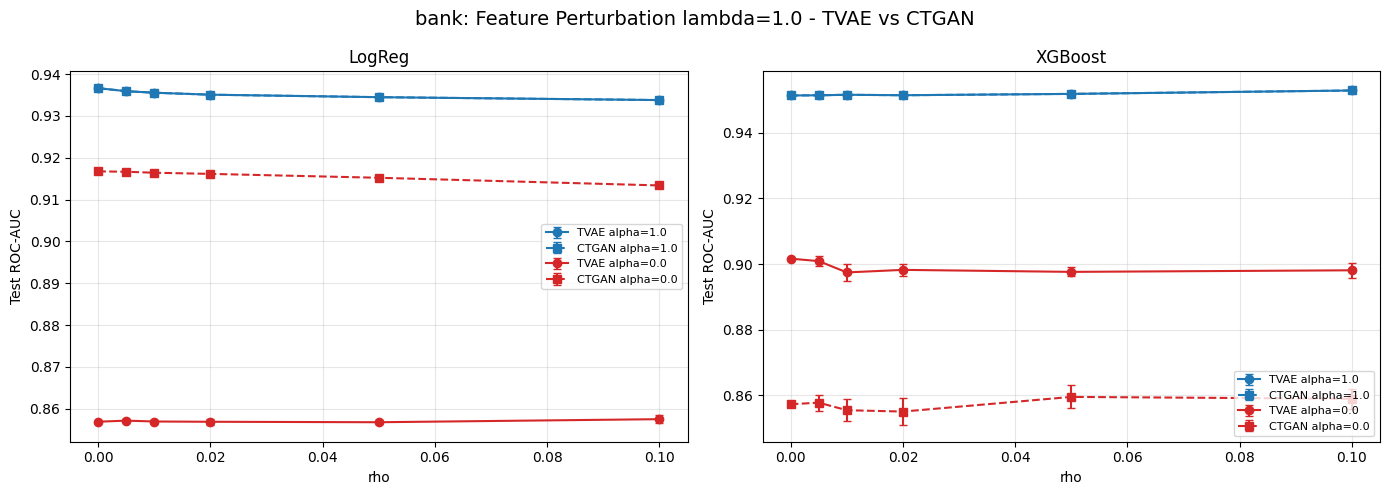

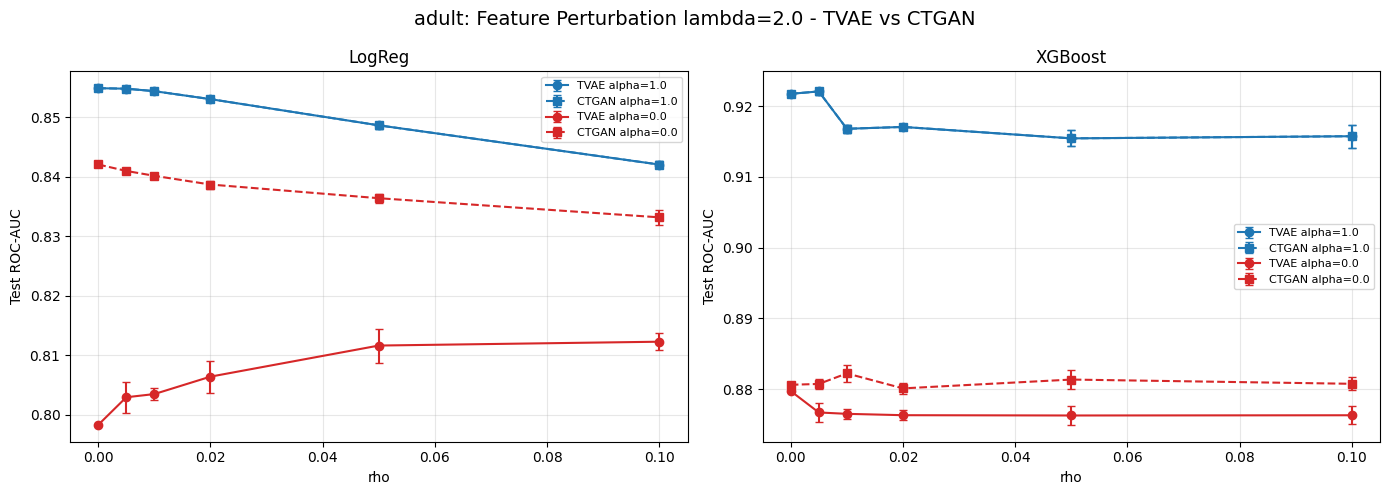

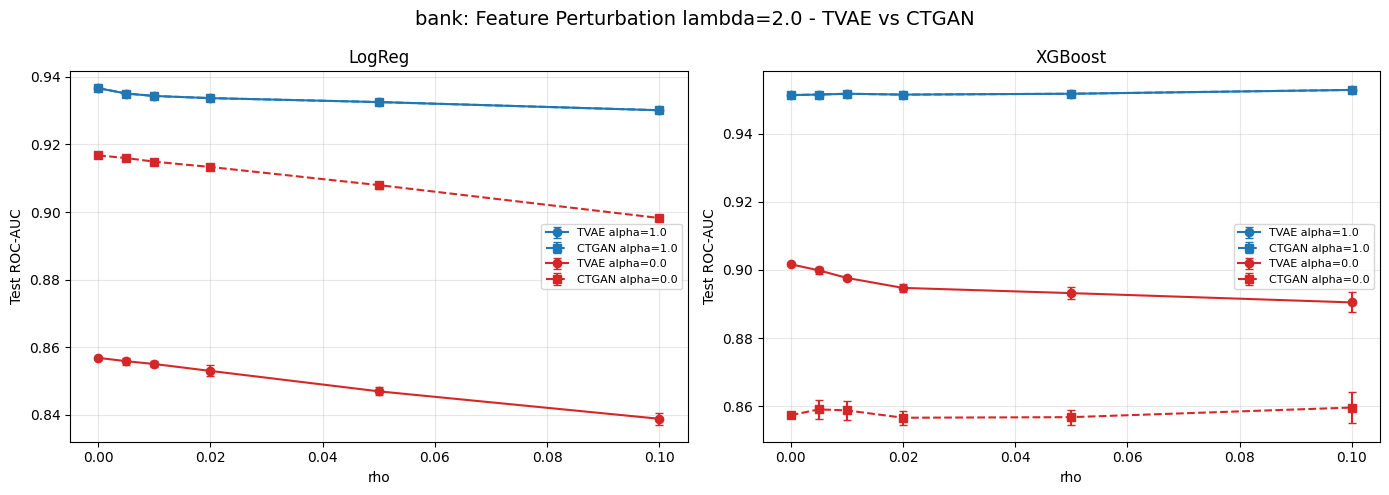

In [ ]:
# Side-by-side degradation curves: TVAE vs CTGAN
def plot_generator_compare(df_tvae, df_ctgan, attack_name, lam_filter=None):
    if 'lambda' in df_tvae.columns and lam_filter is not None:
        df_tvae = df_tvae[(df_tvae['lambda'] == lam_filter) | (df_tvae['rho'] == 0.0)].copy()
        df_tvae.loc[df_tvae['rho'] == 0.0, 'lambda'] = lam_filter
    if 'lambda' in df_ctgan.columns and lam_filter is not None:
        df_ctgan = df_ctgan[(df_ctgan['lambda'] == lam_filter) | (df_ctgan['rho'] == 0.0)].copy()
        df_ctgan.loc[df_ctgan['rho'] == 0.0, 'lambda'] = lam_filter

    for name in df_tvae['dataset'].unique():
        fig, axes = plt.subplots(1, len(CORE_MODELS), figsize=(7*len(CORE_MODELS), 5))
        if len(CORE_MODELS) == 1: axes = [axes]

        for j, mname in enumerate(CORE_MODELS):
            for alpha, color in [(1.0, 'tab:blue'), (0.0, 'tab:red')]:
                # TVAE
                sub = df_tvae[(df_tvae['dataset']==name) & (df_tvae['model']==mname) &
                              (df_tvae['alpha']==alpha)]
                agg = sub.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                lbl_t = f'TVAE alpha={alpha:.1f}'
                axes[j].errorbar(agg['rho'], agg['mean'], yerr=agg['std'],
                                 marker='o', capsize=3, color=color, linestyle='-', label=lbl_t)

                # CTGAN
                if len(df_ctgan) > 0:
                    sub_c = df_ctgan[(df_ctgan['dataset']==name) & (df_ctgan['model']==mname) &
                                     (df_ctgan['alpha']==alpha)]
                    agg_c = sub_c.groupby('rho')['test_auc'].agg(['mean','std']).reset_index()
                    lbl_c = f'CTGAN alpha={alpha:.1f}'
                    axes[j].errorbar(agg_c['rho'], agg_c['mean'], yerr=agg_c['std'],
                                     marker='s', capsize=3, color=color, linestyle='--', label=lbl_c)

            axes[j].set_xlabel('rho')
            axes[j].set_ylabel('Test ROC-AUC')
            axes[j].set_title(f'{mname}')
            axes[j].legend(fontsize=8)
            axes[j].grid(True, alpha=0.3)

        suffix = f' lambda={lam_filter}' if lam_filter else ''
        plt.suptitle(f'{name}: {attack_name}{suffix} - TVAE vs CTGAN', fontsize=14)
        plt.tight_layout()
        fname = f'figures/tvae/{name}_{attack_name.lower().replace(" ","_")}{("_lam"+str(lam_filter)) if lam_filter else ""}_tvae_vs_ctgan.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()

if len(lf_r1_ctgan) > 0:
    plot_generator_compare(lf_r1_tvae, lf_r1_ctgan, 'Label Flipping')
if len(fp_r1_ctgan) > 0:
    for lam in LAMBDAS:
        plot_generator_compare(fp_r1_tvae, fp_r1_ctgan, 'Feature Perturbation', lam_filter=lam)

Privacy metrics: TVAE vs CTGAN
dataset generator   mia_tp   mia_fp  mia_advantage  dcr_mean  dcr_median  dcr_min  dcr_5pctl  nndr_mean  nndr_median
  adult      TVAE 0.502252 0.493168       0.009085  1.363981    1.156021 0.293055   1.003381   0.925721     0.958087
   bank      TVAE 0.501254 0.496237       0.005018  1.283150    1.085790 0.003839   0.195854   0.810817     0.889844
  adult     CTGAN 0.500256 0.499156       0.001100  1.898542    1.618340 0.001599   0.222022   0.833413     0.892682
   bank     CTGAN 0.501821 0.494538       0.007283  1.852144    1.623964 0.010843   0.499335   0.872128     0.920577


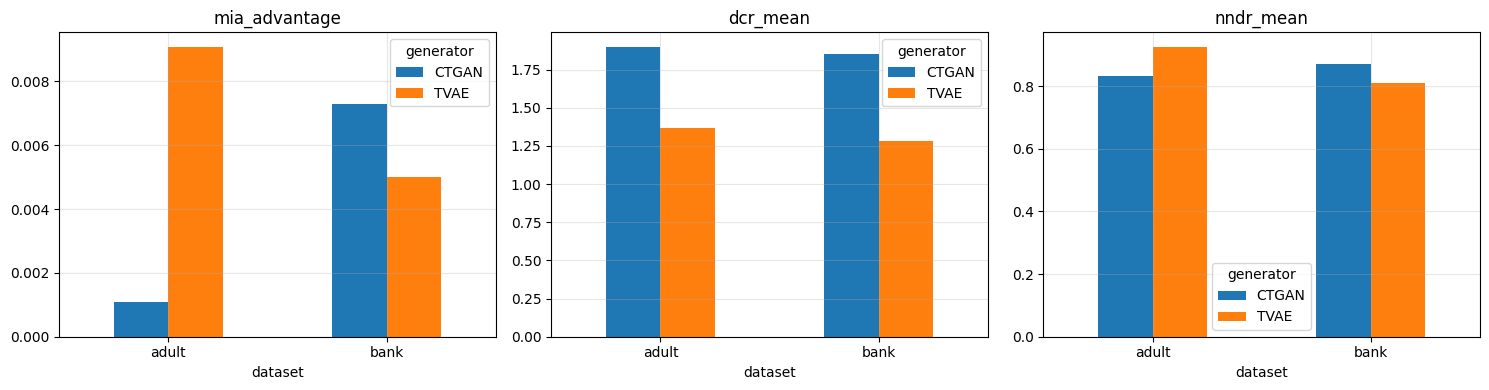

In [ ]:
# Privacy comparison
if len(priv_ctgan) > 0:
    combined_priv = pd.concat([priv_tvae, priv_ctgan], ignore_index=True)
    print('Privacy metrics: TVAE vs CTGAN')
    print(combined_priv.to_string(index=False))
    combined_priv.to_csv('results/tvae/privacy_combined.csv', index=False)

    # Bar plot
    metrics_to_plot = ['mia_advantage', 'dcr_mean', 'nndr_mean']
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(15, 4))
    for j, metric in enumerate(metrics_to_plot):
        pivot = combined_priv.pivot_table(index='dataset', columns='generator', values=metric)
        pivot.plot.bar(ax=axes[j])
        axes[j].set_title(metric)
        axes[j].tick_params(axis='x', rotation=0)
        axes[j].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('figures/tvae/privacy_tvae_vs_ctgan.png', dpi=150, bbox_inches='tight')
    plt.show()

## 18. Сводные таблицы TVAE-эксперимента

In [ ]:
def build_summary(df, attack_label, rho_values=[0.0, 0.02, 0.05, 0.10]):
    rows = []
    for name in df['dataset'].unique():
        for mname in CORE_MODELS:
            for alpha in ALPHAS:
                sub = df[(df['dataset']==name) & (df['model']==mname) & (df['alpha']==alpha)]
                row = {'dataset': name, 'model': mname, 'alpha': alpha}
                for rho in rho_values:
                    vals = sub[sub['rho']==rho]['test_auc']
                    row[f'rho={rho}'] = f'{vals.mean():.4f}+/-{vals.std():.4f}' if len(vals)>0 else '-'
                rows.append(row)
    return pd.DataFrame(rows)

print('TVAE Label Flipping (R1):')
print(build_summary(lf_r1_tvae, 'LF').to_string(index=False))

print('\nTVAE Feature Perturbation R1 (lambda=1.0):')
fp_lam1 = fp_r1_tvae[(fp_r1_tvae['lambda'].isin([1.0, 0.0]))].copy()
fp_lam1.loc[fp_lam1['rho']==0.0, 'lambda'] = 1.0
print(build_summary(fp_lam1, 'FP').to_string(index=False))

print('\nTVAE LF Regime 2:')
print(build_summary(lf_r2_tvae, 'LF-R2').to_string(index=False))

build_summary(lf_r1_tvae, 'LF').to_csv('results/tvae/summary_lf_r1_tvae.csv', index=False)
build_summary(fp_lam1, 'FP').to_csv('results/tvae/summary_fp_r1_tvae.csv', index=False)
build_summary(lf_r2_tvae, 'LF-R2').to_csv('results/tvae/summary_lf_r2_tvae.csv', index=False)

TVAE Label Flipping (R1):
dataset   model  alpha         rho=0.0        rho=0.02        rho=0.05         rho=0.1
  adult  LogReg   0.00 0.7983+/-0.0000 0.8014+/-0.0015 0.8015+/-0.0024 0.8011+/-0.0076
  adult  LogReg   0.25 0.8422+/-0.0000 0.8416+/-0.0006 0.8404+/-0.0006 0.8375+/-0.0022
  adult  LogReg   0.50 0.8504+/-0.0000 0.8504+/-0.0003 0.8498+/-0.0006 0.8481+/-0.0014
  adult  LogReg   0.75 0.8537+/-0.0000 0.8535+/-0.0002 0.8529+/-0.0005 0.8516+/-0.0010
  adult  LogReg   1.00 0.8548+/-0.0000 0.8546+/-0.0003 0.8540+/-0.0008 0.8520+/-0.0016
  adult XGBoost   0.00 0.8797+/-0.0000 0.8677+/-0.0023 0.8607+/-0.0033 0.8480+/-0.0069
  adult XGBoost   0.25 0.9016+/-0.0000 0.8964+/-0.0019 0.8915+/-0.0019 0.8830+/-0.0037
  adult XGBoost   0.50 0.9131+/-0.0000 0.9089+/-0.0011 0.9044+/-0.0018 0.8947+/-0.0036
  adult XGBoost   0.75 0.9180+/-0.0000 0.9137+/-0.0014 0.9116+/-0.0040 0.9002+/-0.0108
  adult XGBoost   1.00 0.9217+/-0.0000 0.9201+/-0.0003 0.9172+/-0.0009 0.9101+/-0.0013
   bank  LogReg  

## 19. Финальный вывод

In [ ]:
print('TVAE EXPERIMENTS COMPLETE')
print()

import glob
print('Files saved:')
for f in sorted(glob.glob('results/tvae/*.csv')):
    print(f'  {f}')
for f in sorted(glob.glob('figures/tvae/*.png')):
    print(f'  {f}')

print()
print('TSTR comparison TVAE vs CTGAN:')
for name, info in tstr_tvae.items():
    print(f'  [{name}] TVAE TSTR gap: {info["gap"]:.4f}')

print()
print('Privacy summary:')
print(priv_tvae.to_string(index=False))

TVAE EXPERIMENTS COMPLETE

Files saved:
  results/tvae/baselines_tvae.csv
  results/tvae/bd_r1_tvae.csv
  results/tvae/bd_r2_tvae.csv
  results/tvae/defense_cleanlab_tvae.csv
  results/tvae/defense_sanitize_tvae.csv
  results/tvae/defense_spectral_tvae.csv
  results/tvae/fp_r1_tvae.csv
  results/tvae/fp_r2_tvae.csv
  results/tvae/lf_r1_tvae.csv
  results/tvae/lf_r2_tvae.csv
  results/tvae/privacy_combined.csv
  results/tvae/privacy_tvae.csv
  results/tvae/summary_fp_r1_tvae.csv
  results/tvae/summary_lf_r1_tvae.csv
  results/tvae/summary_lf_r2_tvae.csv
  figures/tvae/adult_bd_r1_tvae.png
  figures/tvae/adult_feature_perturbation_lam0.5_r1_tvae.png
  figures/tvae/adult_feature_perturbation_lam0.5_tvae_vs_ctgan.png
  figures/tvae/adult_feature_perturbation_lam1.0_r1_tvae.png
  figures/tvae/adult_feature_perturbation_lam1.0_tvae_vs_ctgan.png
  figures/tvae/adult_feature_perturbation_lam2.0_r1_tvae.png
  figures/tvae/adult_feature_perturbation_lam2.0_tvae_vs_ctgan.png
  figures/tvae/adult_